# Clinical ML — Bone Marrow Transplantation
# Data Processing Pipeline

---

| Field | Detail |
|---|---|
| **Project** | Bone Marrow Transplantation Outcome Prediction |
| **Team** | GROUPE-4 |
| **Target** | `survival_status` (0 = survived · 1 = deceased) |
| **Dataset** | `csv_result-bone-marrow.csv` (~190 patients) |

---

## Objectif

This notebook consolidates **all 10 individual data scripts** from the GROUPE-4 repository into a single, reproducible, end-to-end preprocessing pipeline. Each section maps directly to one or more source scripts and documents exactly what was merged and why.

### Pipeline Overview

```
Raw CSV
  │
  ├─ [1] Setup & Imports
  ├─ [2] Load & Inspect Raw Data
  ├─ [3] Clean Data & Optimise Memory       
  ├─ [4] Statistical Profiling             
  ├─ [5] Distribution Analysis             
  ├─ [6] Per-Variable Distribution Plots    
  ├─ [7] Outlier Detection (IQR + Z-Score)  
  ├─ [8] Outlier Treatment (P1/P99 Clip)   
  ├─ [9] Log Transformations                
  ├─ [10] Spearman Correlation Heatmap      
  ├─ [11] Multicollinearity Reduction       
  ├─ [12] Bivariate & Class Distribution    
  └─ [13] Save Outputs & Pipeline Report
```

> ⚙️ **Update `RAW_PATH`** in Section 2 to point to your local CSV before running.

---

## 1. Setup & Imports

All libraries used across the original 10 scripts are imported here in one place.

In [2]:
# ============================================================
#  1. SETUP & IMPORTS
# ============================================================

import json
import logging
import os
import sys
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis, skew, zscore
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")

# ── Logging ──────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── Global plot style ─────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

print("=" * 60)
print("  CLINICAL ML — BMT DATA PROCESSING PIPELINE")
print("=" * 60)
print(f"  Python  : {sys.version.split()[0]}")
print(f"  Pandas  : {pd.__version__}")
print(f"  NumPy   : {np.__version__}")
print("-" * 60)
print("✓ All imports successful")
print("=" * 60)

  CLINICAL ML — BMT DATA PROCESSING PIPELINE
  Python  : 3.12.3
  Pandas  : 2.3.3
  NumPy   : 2.4.3
------------------------------------------------------------
✓ All imports successful


---

## 2. Constants & Configuration

All threshold values and column lists that were previously **scattered across 10 separate scripts** are centralised here. Change them once — they propagate to every section automatically.

In [25]:
# ============================================================
#  2. CONSTANTS & CONFIGURATION
# ============================================================

# ── Paths ─────────────────────────────────────────────────────
RAW_PATH      = Path("data/raw/csv_result-bone-marrow.csv")
PROCESSED_DIR = Path("data/processed")
PLOTS_DIR     = Path("data/plots")
REPORTS_DIR   = Path("data/reports")

for d in [PROCESSED_DIR, PLOTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Target variable ───────────────────────────────────────────
TARGET_COL = "survival_status"

# ── Columns to drop (leakage / non-predictive) ───────────────
# Source: data_processing.py → clean_data()
DROP_COLUMNS: List[str] = [
    "id", "survival_time", "time_to_aGvHD_III_IV",
    "Relapse", "time", "date",
]

# ── Clinical continuous features (cell-dosage metrics) ───────
# Source: data_processing.py → handle_outliers() + OutLayers.py
CLINICAL_CONTINUOUS: List[str] = [
    "CD34kgx10d6", "CD3dkgx10d8", "WBCx10d8",
    "MNCkgx10d8", "RNCdkgx10d8",
]

# ── Features for per-variable distribution plots ─────────────
# Source: Heat-map.py + OutLayers.py
DISTRIBUTION_FEATURES: List[str] = [
    "Donorage", "Recipientage", "CD34kgx10d6",
    "CD3dCD34", "CD3dkgx10d8", "Rbodymass",
]

# ── Categorical features for survival plots ───────────────────
# Source: rest.py
CATEGORICAL_FEATURES: List[str] = [
    "Stemcellsource", "Riskgroup", "Disease", "Donorgender",
]

# ── Thresholds ────────────────────────────────────────────────
SKEWNESS_THRESHOLD         = 0.75   # data_processing.py / Data--analysis.py
MULTICOLLINEARITY_THRESHOLD = 0.80  # Heat_map.py / Focused-data.py

print("=" * 60)
print("  CONFIGURATION SUMMARY")
print("=" * 60)
print(f"  RAW_PATH            : {RAW_PATH}")
print(f"  TARGET_COL          : {TARGET_COL}")
print(f"  SKEWNESS_THRESHOLD  : {SKEWNESS_THRESHOLD}")
print(f"  MULTICOLLIN. THRESH : {MULTICOLLINEARITY_THRESHOLD}")
print(f"  DROP_COLUMNS        : {DROP_COLUMNS}")
print("=" * 60)
print("✓ Constants set")

  CONFIGURATION SUMMARY
  RAW_PATH            : data/raw/csv_result-bone-marrow.csv
  TARGET_COL          : survival_status
  SKEWNESS_THRESHOLD  : 0.75
  MULTICOLLIN. THRESH : 0.8
  DROP_COLUMNS        : ['id', 'survival_time', 'time_to_aGvHD_III_IV', 'Relapse', 'time', 'date']
✓ Constants set


---

## 3. Load & Inspect Raw Data

First look at shape, dtypes, missing values, and class balance — the same diagnostics that were spread across `Data_analysis.py` and `Data--analysis.py`.

In [4]:
# ============================================================
#  3. LOAD & INSPECT RAW DATA
# ============================================================

if not RAW_PATH.exists():
    # ── Synthetic fallback for demo purposes ─────────────────
    print("⚠️  Dataset not found — generating synthetic BMT data for demonstration…")
    np.random.seed(42)
    n = 190
    df_raw = pd.DataFrame({
        "id":                    range(1, n + 1),
        "survival_time":         np.random.exponential(365, n),
        "Donorage":              np.random.normal(35, 10, n).clip(18, 65),
        "Recipientage":          np.random.normal(28, 12, n).clip(1, 60),
        "Rbodymass":             np.random.normal(55, 18, n).clip(10, 120),
        "CD34kgx10d6":           np.abs(np.random.exponential(4.5, n)),
        "CD3dkgx10d8":           np.abs(np.random.exponential(3.2, n)),
        "CD3dCD34":              np.abs(np.random.exponential(0.8, n)),
        "WBCx10d8":              np.abs(np.random.exponential(8.5, n)),
        "MNCkgx10d8":            np.abs(np.random.exponential(5.0, n)),
        "RNCdkgx10d8":           np.abs(np.random.exponential(2.1, n)),
        "Stemcellsource":        np.random.choice(["PBSC", "BM", "CB"], n),
        "Riskgroup":             np.random.choice(["low", "standard", "high"], n),
        "Disease":               np.random.choice(["ALL", "AML", "CML", "MDS"], n),
        "Donorgender":           np.random.choice(["M", "F"], n),
        "Relapse":               np.random.binomial(1, 0.25, n),
        "survival_status":       np.random.binomial(1, 0.52, n),
    })
    # Inject ~8% missing values in clinical columns
    for col in ["CD34kgx10d6", "CD3dkgx10d8", "WBCx10d8"]:
        idx = np.random.choice(df_raw.index, size=int(0.08 * n), replace=False)
        df_raw.loc[idx, col] = np.nan
    RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_raw.to_csv(RAW_PATH, index=False)
    print("✓ Synthetic dataset saved to:", RAW_PATH)

df_raw = pd.read_csv(RAW_PATH)

print("\n" + "=" * 60)
print("  RAW DATA REPORT")
print("=" * 60)
print(f"  Shape             : {df_raw.shape[0]} rows × {df_raw.shape[1]} cols")
print(f"  Memory usage      : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB")
print(f"  Missing cells     : {df_raw.isnull().sum().sum()}")
print("-" * 60)
if TARGET_COL in df_raw.columns:
    vc = df_raw[TARGET_COL].value_counts()
    print("  Class distribution:")
    print(f"    Survived (0) : {vc.get(0,0):>4}  ({vc.get(0,0)/len(df_raw)*100:.1f}%)")
    print(f"    Deceased (1) : {vc.get(1,0):>4}  ({vc.get(1,0)/len(df_raw)*100:.1f}%)")
print("=" * 60)
print("✓ Raw data loaded")

df_raw.head()


  RAW DATA REPORT
  Shape             : 190 rows × 17 cols
  Memory usage      : 57.9 KB
  Missing cells     : 45
------------------------------------------------------------
  Class distribution:
    Survived (0) :  106  (55.8%)
    Deceased (1) :   84  (44.2%)
✓ Raw data loaded


,id,survival_time,Donorage,Recipientage,Rbodymass,CD34kgx10d6,CD3dkgx10d8,CD3dCD34,WBCx10d8,MNCkgx10d8,RNCdkgx10d8,Stemcellsource,Riskgroup,Disease,Donorgender,Relapse,survival_status
0,1,171.282853,37.598828,39.701437,41.261335,9.128272,5.414122,0.025677,2.305291,2.124002,3.575397,CB,standard,AML,M,0,1
1,2,1098.694322,42.818229,26.235311,22.512122,3.007441,0.813346,2.201755,3.971288,18.567952,0.504372,BM,standard,CML,F,0,1
2,3,480.612178,22.630493,18.094034,25.704236,10.122928,0.810777,0.042696,2.191513,5.121776,1.480335,CB,standard,MDS,M,1,1
3,4,333.224032,21.795434,24.143370,55.865529,7.239215,2.463914,0.623481,0.646111,8.643376,3.857669,BM,low,AML,F,1,1
4,5,61.913078,40.219416,32.955177,59.675005,2.491905,2.876142,0.987712,7.862072,0.710841,2.771504,CB,standard,ALL,F,0,1


In [5]:
# ── Missing value audit ───────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %":     missing_pct,
    "Dtype":         df_raw.dtypes
}).loc[missing > 0].sort_values("Missing %", ascending=False)

print("=" * 50)
print("  MISSING VALUES")
print("=" * 50)
if missing_report.empty:
    print("  ✓ No missing values detected")
else:
    print(missing_report.to_string())
print("=" * 50)

  MISSING VALUES
             Missing Count  Missing %    Dtype
CD34kgx10d6             15       7.89  float64
CD3dkgx10d8             15       7.89  float64
WBCx10d8                15       7.89  float64


---

## 4. Clean Data & Optimise Memory

**Source scripts:** `data_processing.py` → `clean_data()` + `optimize_memory()`

Three operations in sequence:
1. **Drop leakage columns** — `id`, `survival_time`, `Relapse`, etc. carry target information or are identifiers with no signal.
2. **Impute missing values** — median for numerics (robust to skew), mode for categoricals.
3. **One-hot encode** categoricals, then **downcast** `float64→float32` and `int64→int32` to reduce RAM by ~50%.

In [26]:
# ============================================================
#  4. CLEAN DATA & OPTIMISE MEMORY
# ============================================================

def optimize_memory(df: pd.DataFrame) -> pd.DataFrame:
    """Downcasts float64→float32 and int64→int32 to reduce RAM."""
    mem_before = df.memory_usage(deep=True).sum() / 1_024
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
        elif df[col].dtype == "int64":
            df[col] = df[col].astype("int32")
    mem_after = df.memory_usage(deep=True).sum() / 1_024
    reduction = (1 - mem_after / mem_before) * 100
    print(f"  Memory: {mem_before:.1f} KB → {mem_after:.1f} KB  (↓ {reduction:.1f}%)")
    return df


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Drop leakage cols, impute NaNs, one-hot encode, optimise memory."""
    # Step 1: Drop leakage / non-predictive columns
    cols_found  = [c for c in DROP_COLUMNS if c in df.columns]
    df = df.drop(columns=cols_found, errors="ignore")
    print(f"  Dropped columns  : {cols_found}")

    # Step 2: Median imputation for numeric NaNs
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    # Step 3: Mode imputation for categorical NaNs
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    for col in cat_cols:
        fill_val = df[col].mode().iloc[0] if not df[col].mode().empty else "Unknown"
        df[col] = df[col].fillna(fill_val)

    # Step 4: One-hot encode
    if len(cat_cols):
        df = pd.get_dummies(df, columns=list(cat_cols), drop_first=True)
        print(f"  One-hot encoded  : {list(cat_cols)}")

    # Step 5: Downcast numeric types
    return optimize_memory(df)


# ── Execute ───────────────────────────────────────────────────
print("=" * 60)
print("  CLEANING & OPTIMISING")
print("=" * 60)
df = clean_data(df_raw.copy())
print(f"  Shape after cleaning : {df.shape}")
print(f"  Remaining NaNs       : {df.isnull().sum().sum()}")
print("=" * 60)
print("✓ clean_data() complete")
df.head()

  CLEANING & OPTIMISING
  Dropped columns  : ['id', 'survival_time', 'Relapse']
  One-hot encoded  : ['Stemcellsource', 'Riskgroup', 'Disease', 'Donorgender']
  Memory: 16.5 KB → 9.0 KB  (↓ 45.1%)
  Shape after cleaning : (190, 18)
  Remaining NaNs       : 0
✓ clean_data() complete


,Donorage,Recipientage,Rbodymass,CD34kgx10d6,CD3dkgx10d8,CD3dCD34,WBCx10d8,MNCkgx10d8,RNCdkgx10d8,survival_status,Stemcellsource_CB,Stemcellsource_PBSC,Riskgroup_low,Riskgroup_standard,Disease_AML,Disease_CML,Disease_MDS,Donorgender_M
0,37.598827,39.701435,41.261333,9.128272,5.414122,0.025677,2.305290,2.124002,3.575397,1,True,False,False,True,True,False,False,True
1,42.818230,26.235312,22.512123,3.007442,0.813346,2.201755,3.971288,18.567951,0.504372,1,False,False,False,True,False,True,False,False
2,22.630493,18.094034,25.704237,10.122928,0.810777,0.042696,2.191513,5.121776,1.480335,1,True,False,False,True,False,False,True,True
3,21.795433,24.143370,55.865528,7.239215,2.463913,0.623481,0.646111,8.643376,3.857669,1,False,False,True,False,True,False,False,False
4,40.219414,32.955177,59.675007,2.491905,2.876143,0.987712,7.862072,0.710841,2.771504,1,True,False,False,True,False,False,False,False


---

## 5. Statistical Profiling



Computes mean, median, skewness, and excess kurtosis for every numeric column.


In [27]:
# ============================================================
#  5. STATISTICAL PROFILING
# ============================================================

def get_statistical_profiling(df: pd.DataFrame) -> pd.DataFrame:
    """Mean, Median, Skewness, Kurtosis for all numeric columns."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    profile = pd.DataFrame({
        "Mean":     df[numeric_cols].mean(),
        "Median":   df[numeric_cols].median(),
        "Skewness": df[numeric_cols].apply(skew, nan_policy="omit"),
        "Kurtosis": df[numeric_cols].apply(kurtosis, nan_policy="omit"),
    }).round(4)
    return profile


profile = get_statistical_profiling(df)
profile.to_csv(REPORTS_DIR / "statistical_profile.csv")

print("=" * 60)
print("  STATISTICAL PROFILE (numeric columns)")
print("=" * 60)
print(f"  Saved to: {REPORTS_DIR}/statistical_profile.csv")
print("✓ Profiling complete")

profile

  STATISTICAL PROFILE (numeric columns)
  Saved to: data/reports/statistical_profile.csv
✓ Profiling complete


,Mean,Median,Skewness,Kurtosis
Donorage,35.9666,36.4223,0.2719,-0.0560
Recipientage,27.6722,27.3653,0.2148,-0.3776
Rbodymass,54.2151,53.9050,0.0097,-0.2009
CD34kgx10d6,4.8706,3.4894,1.8354,3.9642
CD3dkgx10d8,3.0343,2.2662,1.9206,5.2849
CD3dCD34,0.8760,0.6147,2.1077,6.5293
WBCx10d8,7.8163,6.2221,2.0909,5.9230
MNCkgx10d8,5.0589,3.3476,1.7851,3.5419
RNCdkgx10d8,1.9995,1.4643,2.4005,8.1599
survival_status,0.4421,0.0000,0.2331,-1.9456


---

## 6. Distribution Analysis — Identifying Skewed Variables



Flags all continuous variables with **|skewness| > 0.75** for log transformation. Columns with zero or negative values are flagged separately — they require `log(1+x)` rather than plain `log(x)`.

In [8]:
# ============================================================
#  6. DISTRIBUTION ANALYSIS
#  Source: Data--analysis.py + data_processing.py → analyze_distributions()
# ============================================================

def analyze_distributions(df: pd.DataFrame) -> List[str]:
    """Identifies continuous variables with |skewness| > SKEWNESS_THRESHOLD."""
    continuous_vars = [
        col for col in df.columns
        if df[col].nunique() > 10
        and pd.api.types.is_numeric_dtype(df[col])
        and col != TARGET_COL
    ]

    results = []
    for col in continuous_vars:
        results.append({
            "Variable":  col,
            "Skewness":  round(df[col].skew(), 4),
            "Min":       round(float(df[col].min()), 4),
            "Max":       round(float(df[col].max()), 4),
            "Zeros":     int((df[col] == 0).sum()),
            "Negatives": int((df[col] < 0).sum()),
        })

    results_df = pd.DataFrame(results).sort_values("Skewness", ascending=False)
    high_skew  = results_df[results_df["Skewness"].abs() > SKEWNESS_THRESHOLD]["Variable"].tolist()
    return results_df, high_skew


skew_table, skewed_cols = analyze_distributions(df)

print("=" * 60)
print(f"  SKEWNESS REPORT  (threshold = {SKEWNESS_THRESHOLD})")
print("=" * 60)
print(skew_table.to_string(index=False))
print("-" * 60)
print(f"  Targeted for log transform : {skewed_cols}")
print("=" * 60)
print("✓ Distribution analysis complete")

  SKEWNESS REPORT  (threshold = 0.75)
    Variable  Skewness     Min      Max  Zeros  Negatives
 RNCdkgx10d8    2.4197  0.0068  13.4515      0          0
    CD3dCD34    2.1245  0.0040   5.9534      0          0
    WBCx10d8    2.1075  0.0645  43.6857      0          0
 CD3dkgx10d8    1.9359  0.0205  18.7249      0          0
 CD34kgx10d6    1.8500  0.0812  27.8199      0          0
  MNCkgx10d8    1.7994  0.0555  28.5644      0          0
    Donorage    0.2740 18.0000  65.0000      0          0
Recipientage    0.2166  1.0000  60.0000      0          0
   Rbodymass    0.0098 10.0000 101.3205      0          0
------------------------------------------------------------
  Targeted for log transform : ['RNCdkgx10d8', 'CD3dCD34', 'WBCx10d8', 'CD3dkgx10d8', 'CD34kgx10d6', 'MNCkgx10d8']
✓ Distribution analysis complete


---

## 7. Per-Variable Distribution Plots

For each variable in `DISTRIBUTION_FEATURES`: a compact boxplot on top and a KDE histogram below, with the skewness value annotated.

Generating per-variable distribution plots…


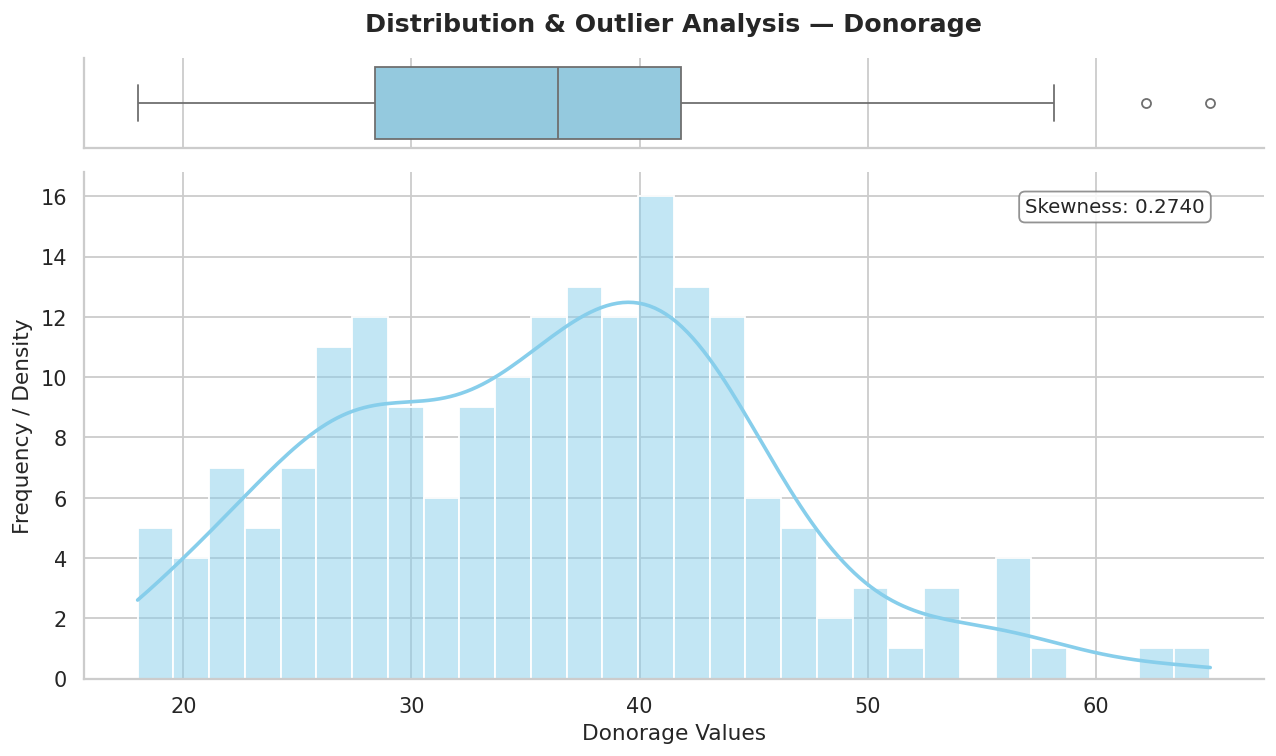

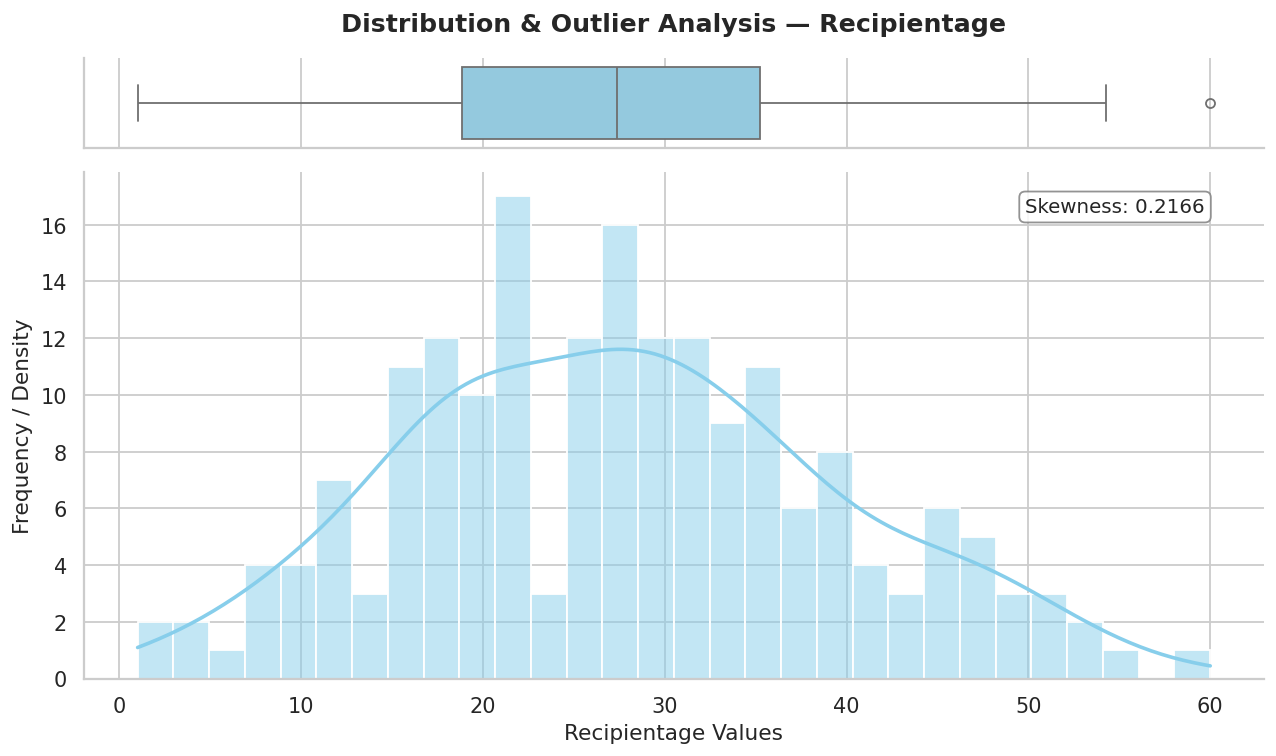

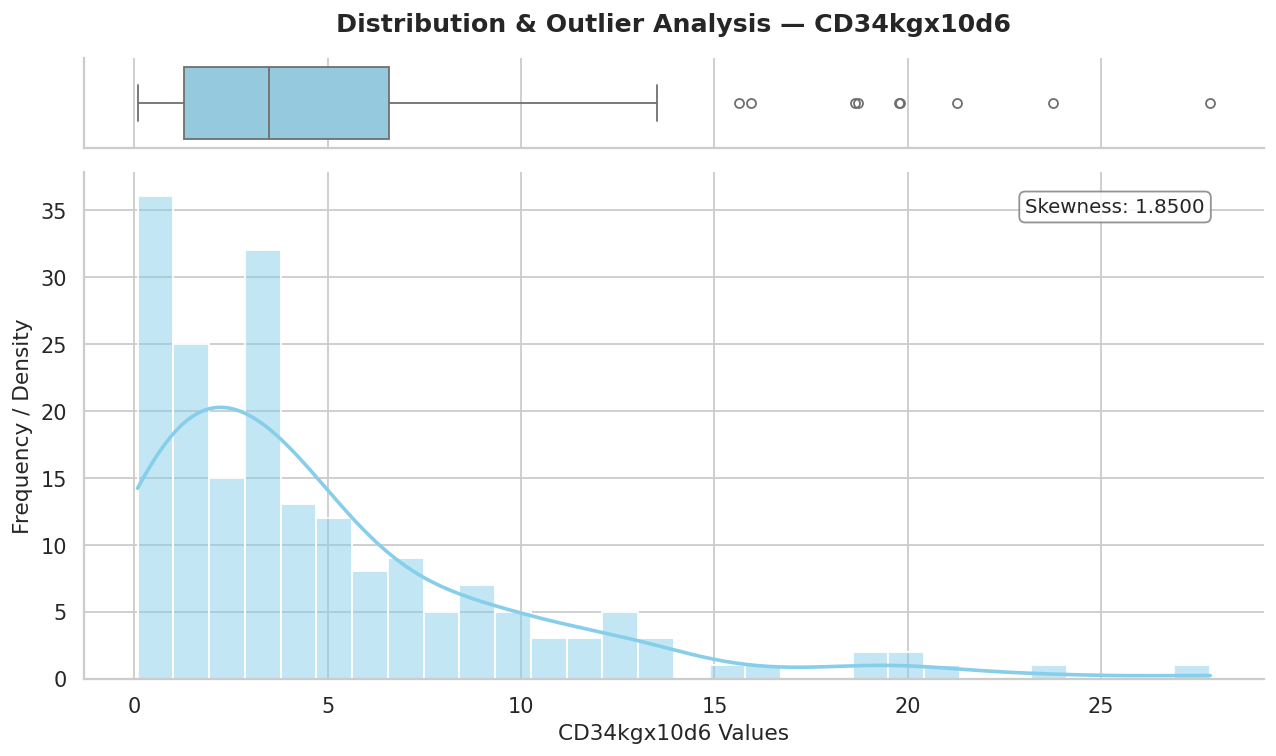

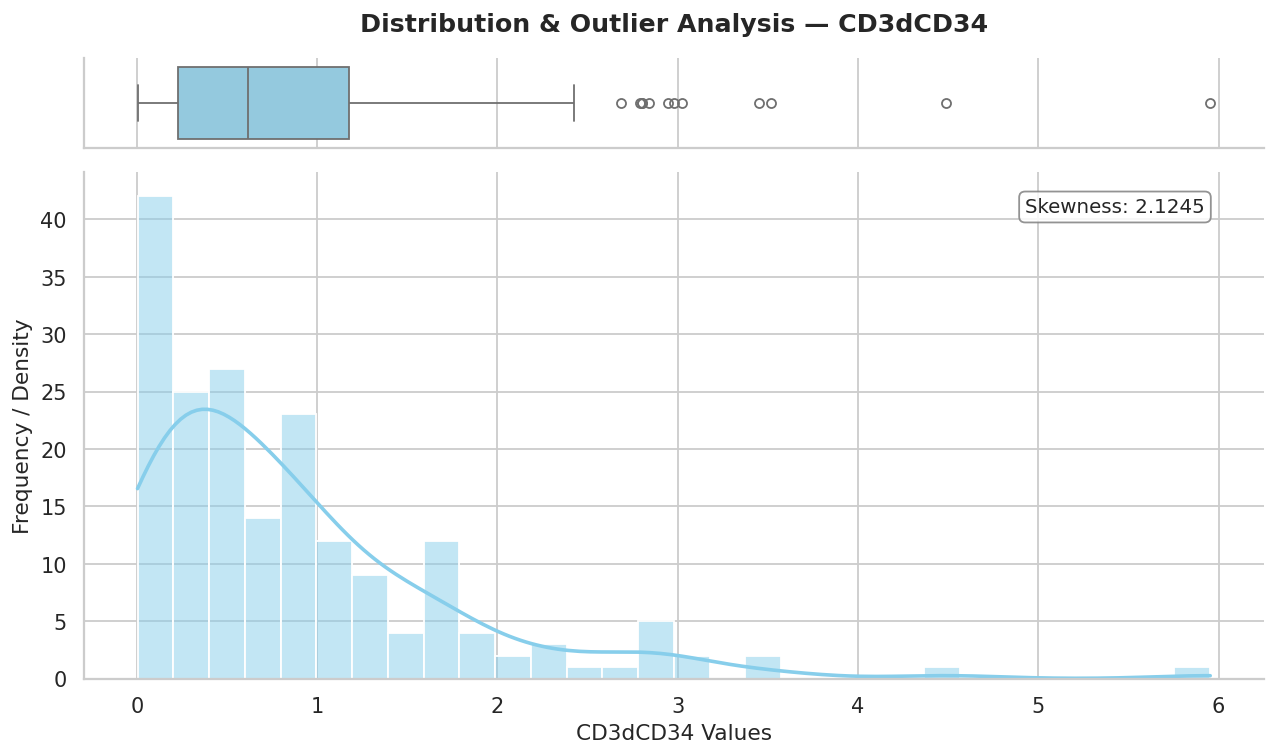

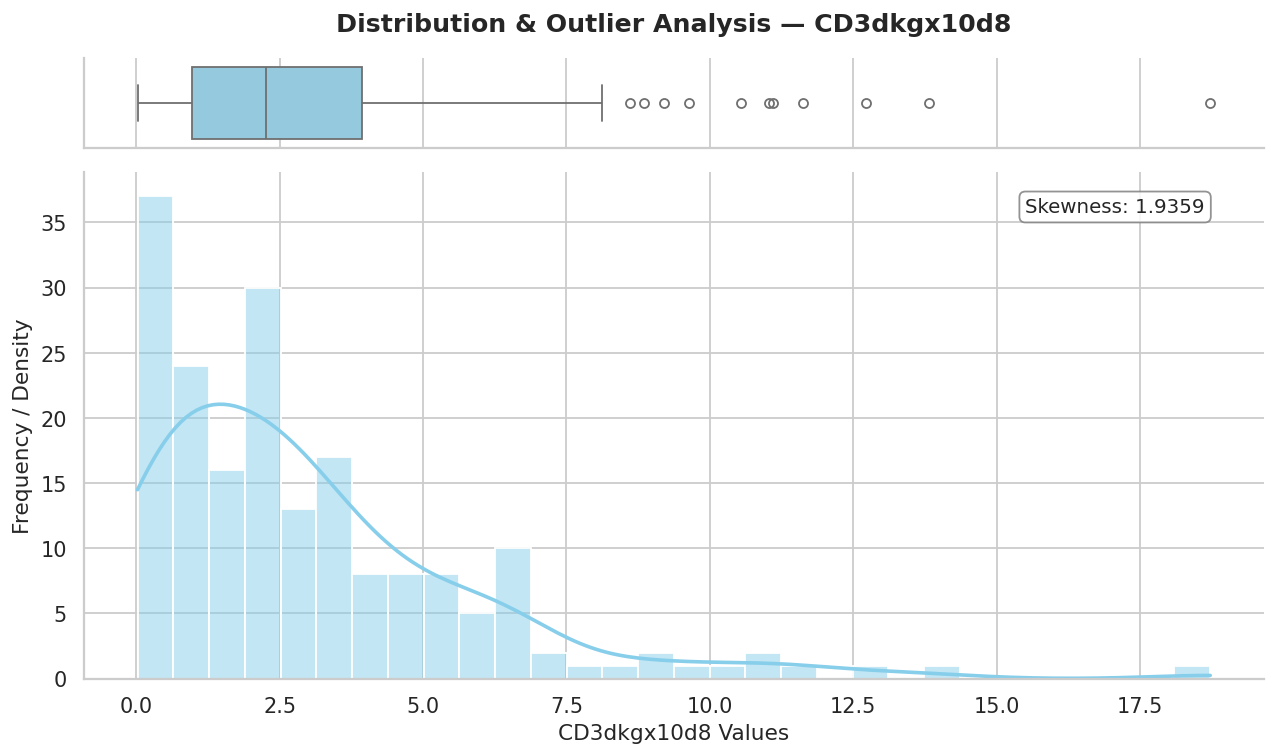

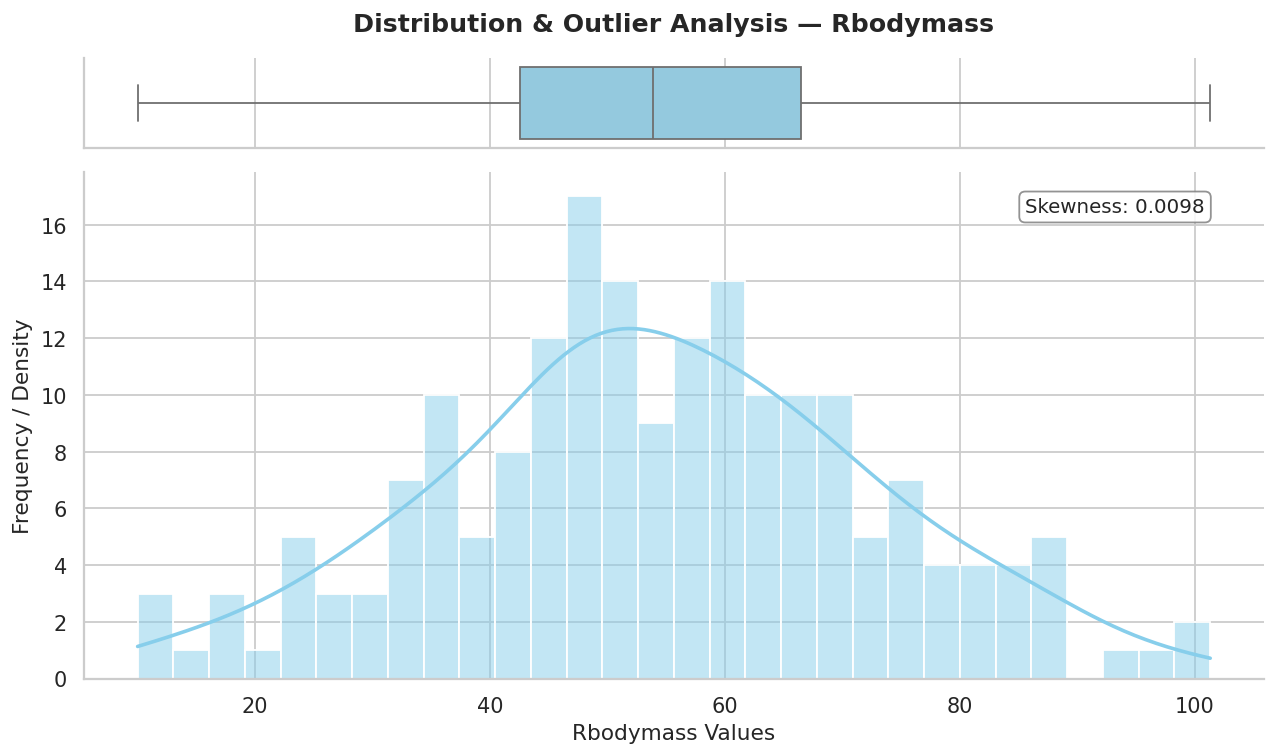

✓ Per-variable plots complete


In [28]:
# ============================================================
#  7. PER-VARIABLE DISTRIBUTION PLOTS
# ============================================================

def plot_per_variable_distributions(df: pd.DataFrame, out_dir: Path) -> None:
    """Boxplot + histogram for each variable in DISTRIBUTION_FEATURES."""
    cols = [c for c in DISTRIBUTION_FEATURES if c in df.columns]
    for col in cols:
        skewness = df[col].skew()
        fig, (ax_box, ax_hist) = plt.subplots(
            2, sharex=True,
            gridspec_kw={"height_ratios": (0.15, 0.85)},
            figsize=(10, 6),
        )
        sns.boxplot(x=df[col], ax=ax_box, color="skyblue", fliersize=5)
        ax_box.set(xlabel="")
        ax_box.set_title(f"Distribution & Outlier Analysis — {col}", fontsize=14, pad=15)
        sns.histplot(df[col], kde=True, ax=ax_hist, color="skyblue", bins=30,
                     line_kws={"linewidth": 2})
        ax_hist.set_xlabel(f"{col} Values", fontsize=12)
        ax_hist.set_ylabel("Frequency / Density", fontsize=12)
        ax_hist.text(
            0.95, 0.95, f"Skewness: {skewness:.4f}",
            transform=ax_hist.transAxes, fontsize=11, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="gray"),
        )
        plt.tight_layout()
        plt.savefig(out_dir / f"{col}_dist.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()


print("Generating per-variable distribution plots…")
plot_per_variable_distributions(df, PLOTS_DIR)
print("✓ Per-variable plots complete")

---

## 8. Outlier Detection — IQR & Z-Score


Two complementary methods:
- **IQR rule**: flags values outside `[Q1 – 1.5×IQR, Q3 + 1.5×IQR]`
- **Z-score rule**: flags values with `|z| > 3`

In [29]:
# ============================================================
#  8. OUTLIER DETECTION — IQR & Z-SCORE
# ============================================================

def detect_outliers_iqr(df: pd.DataFrame, columns: List[str]) -> List[int]:
    """Row indices flagged by the 1.5 × IQR rule."""
    idx: set = set()
    for col in columns:
        if col not in df.columns:
            continue
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        idx.update(df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)].index)
    return list(idx)


def detect_outliers_zscore(df: pd.DataFrame, columns: List[str]) -> List[int]:
    """Row indices where |z-score| > 3 in any listed column."""
    idx: set = set()
    for col in columns:
        if col not in df.columns:
            continue
        valid = df[col].dropna()
        z = np.abs(zscore(valid))
        idx.update(valid[z > 3].index)
    return list(idx)


# ── Outlier statistics table (OutLayers.py v1 style) ─────────
existing_cols = [c for c in DISTRIBUTION_FEATURES if c in df.columns]
total_rows = len(df)
outlier_stats = []
for col in existing_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = len(df[(df[col] < lo) | (df[col] > hi)])
    outlier_stats.append({
        "Variable":       col,
        "Lower Bound":    round(lo, 4),
        "Upper Bound":    round(hi, 4),
        "Outlier Count":  n_out,
        "Percentage (%)":  round(n_out / total_rows * 100, 2),
    })

stats_df = pd.DataFrame(outlier_stats)

print("=" * 60)
print("  OUTLIER STATISTICS (IQR method)")
print("=" * 60)
print(stats_df.to_string(index=False))

iqr_idx = detect_outliers_iqr(df, CLINICAL_CONTINUOUS)
z_idx   = detect_outliers_zscore(df, CLINICAL_CONTINUOUS)
print("-" * 60)
print(f"  IQR outlier rows    : {len(iqr_idx)}")
print(f"  Z-score outlier rows: {len(z_idx)}")
print("=" * 60)
print("✓ Outlier detection complete")

  OUTLIER STATISTICS (IQR method)
    Variable  Lower Bound  Upper Bound  Outlier Count  Percentage (%)
    Donorage       8.2877      61.9292              2            1.05
Recipientage      -5.8446      59.9182              1            0.53
 CD34kgx10d6      -6.6362      14.5011              9            4.74
    CD3dCD34      -1.1895       2.5989             12            6.32
 CD3dkgx10d8      -3.5077       8.4129             11            5.79
   Rbodymass       6.6925     102.3342              0            0.00
------------------------------------------------------------
  IQR outlier rows    : 51
  Z-score outlier rows: 17
✓ Outlier detection complete


In [ ]:
# ── Combined boxplot — OutLayers.py v1 style ─────────────────
cols = [c for c in DISTRIBUTION_FEATURES if c in df.columns]
n = len(cols)
nrows = (n + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(15, 5 * nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue", fliersize=5)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Combined Boxplots — Distribution Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "combined_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("✓ Combined boxplots saved")

---

## 9. Outlier Treatment — P1/P99 Clipping


**Why clipping instead of removal?**  
The BMT dataset has ~190 patients. Removing rows would significantly reduce statistical power. Clipping at the **1st and 99th percentiles** neutralises extreme tails while preserving every observation.

Side-by-side before/after boxplots confirm the treatment effect.

In [12]:
# ============================================================
#  9. OUTLIER TREATMENT — P1/P99 CLIPPING
# ============================================================

def clip_outliers(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """Generalised P1/P99 clipping for any column list."""
    df_clipped = df.copy()
    for col in columns:
        if col not in df_clipped.columns:
            continue
        lo = df_clipped[col].quantile(0.01)
        hi = df_clipped[col].quantile(0.99)
        df_clipped[col] = df_clipped[col].clip(lower=lo, upper=hi)
    return df_clipped


# ── Execute clipping ──────────────────────────────────────────
df_before_clip = df.copy()
clip_targets   = [c for c in CLINICAL_CONTINUOUS if c in df.columns]

print("=" * 60)
print("  P1/P99 CLIPPING — CLINICAL CONTINUOUS VARIABLES")
print("=" * 60)
for col in clip_targets:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"  ✓ {col:<20}  clipped to [{lo:.4f}, {hi:.4f}]")
print("=" * 60)
print("✓ Clipping complete")

  P1/P99 CLIPPING — CLINICAL CONTINUOUS VARIABLES
  ✓ CD34kgx10d6           clipped to [0.0966, 21.3125]
  ✓ CD3dkgx10d8           clipped to [0.0373, 12.7274]
  ✓ WBCx10d8              clipped to [0.2028, 40.2960]
  ✓ MNCkgx10d8            clipped to [0.0610, 20.9558]
  ✓ RNCdkgx10d8           clipped to [0.0196, 10.1106]
✓ Clipping complete


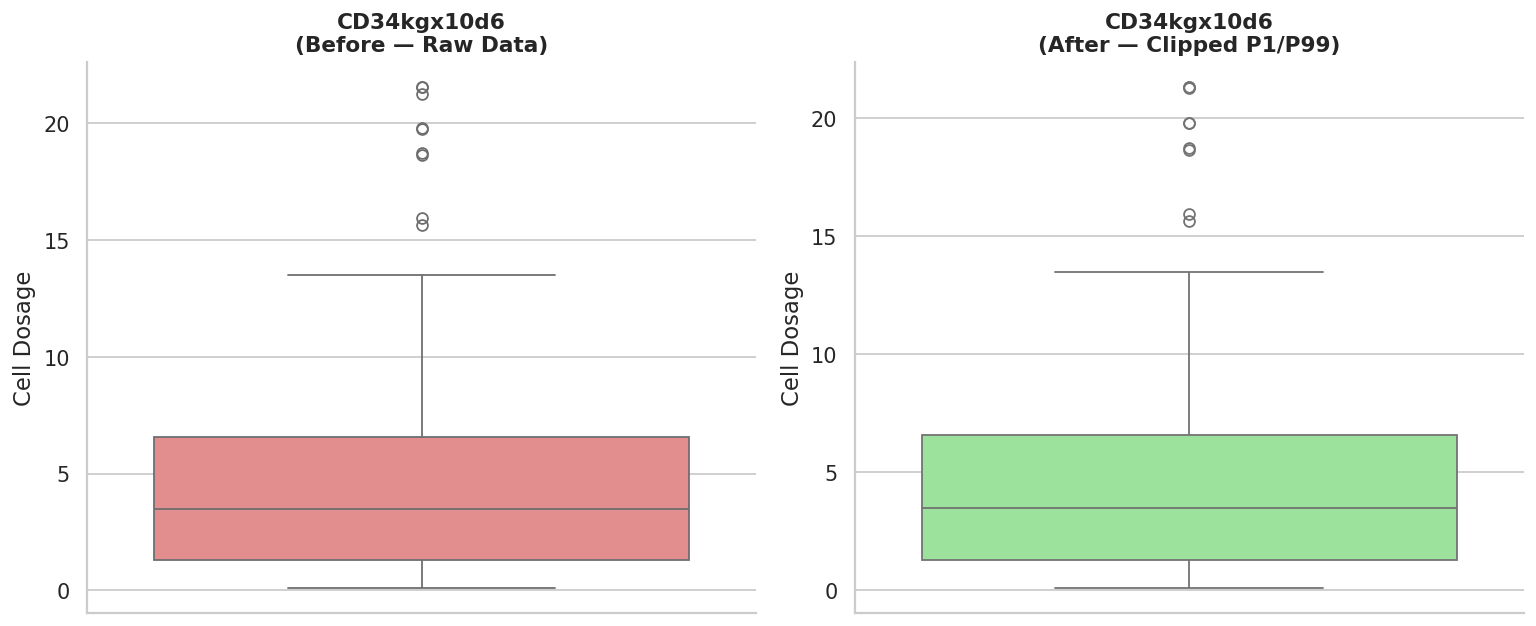

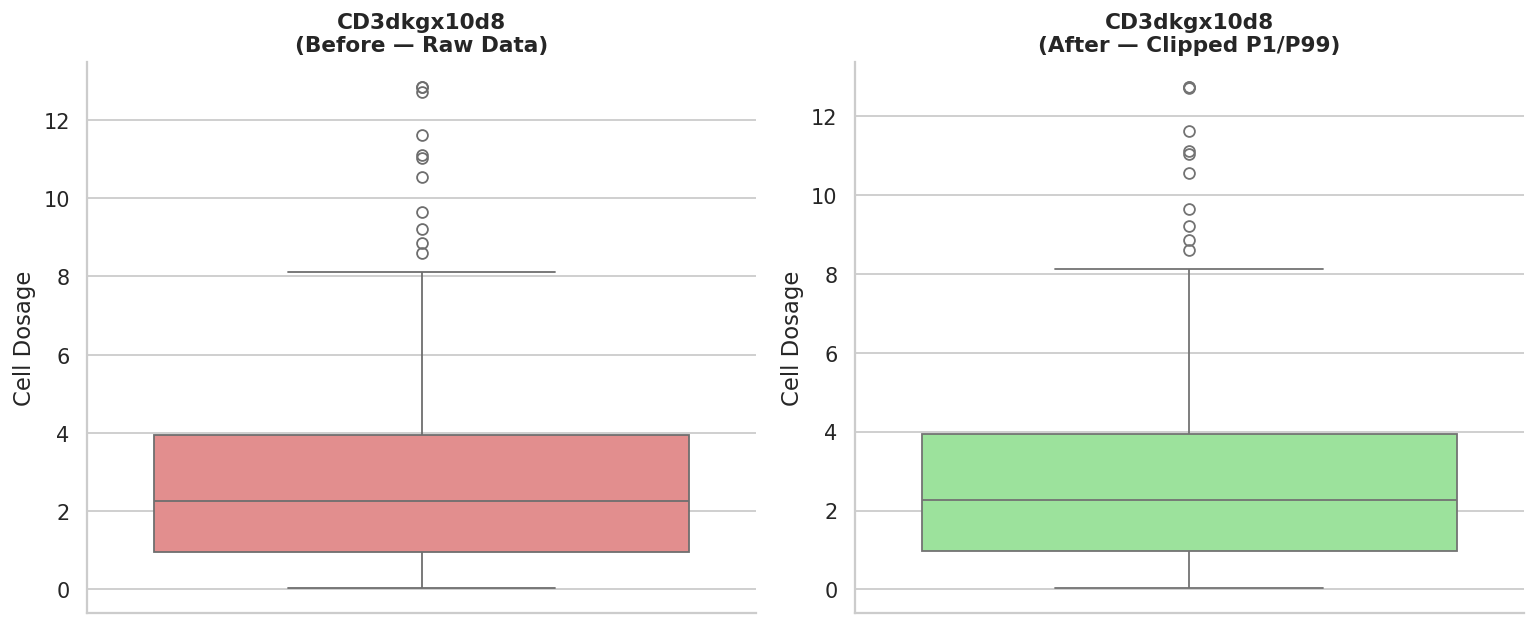

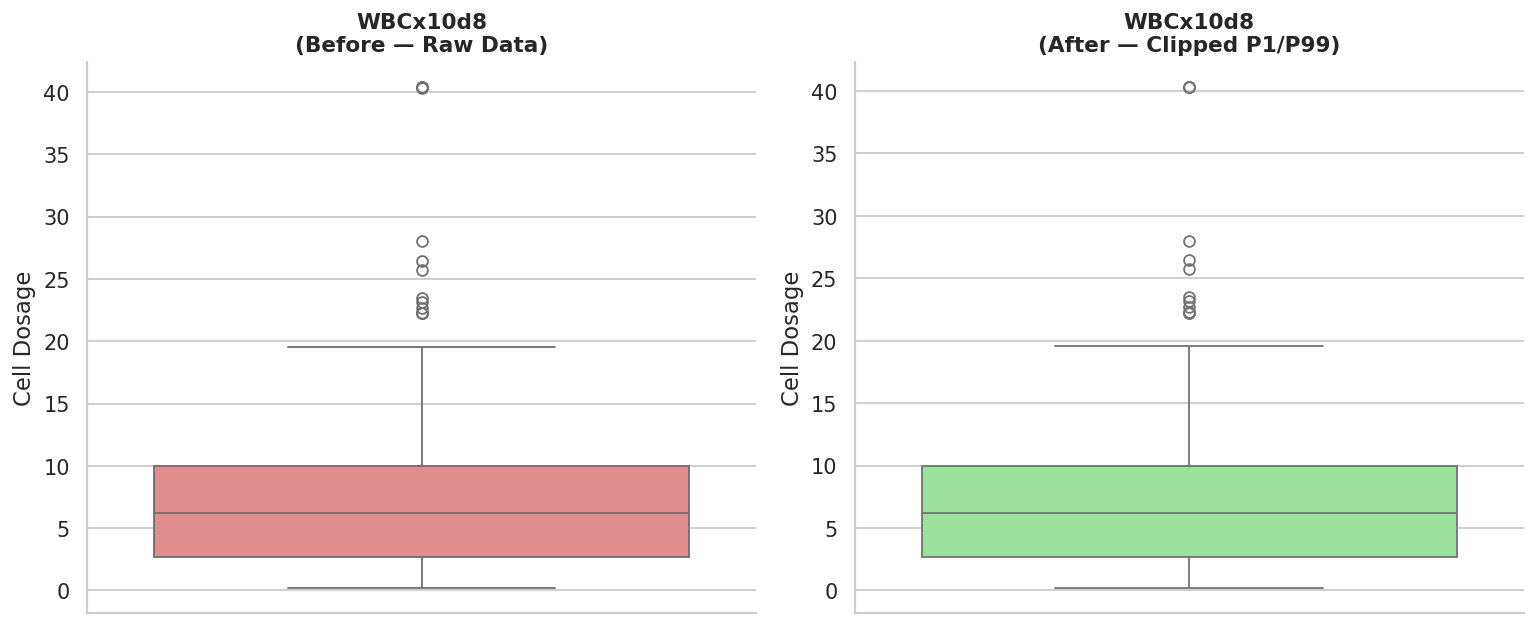

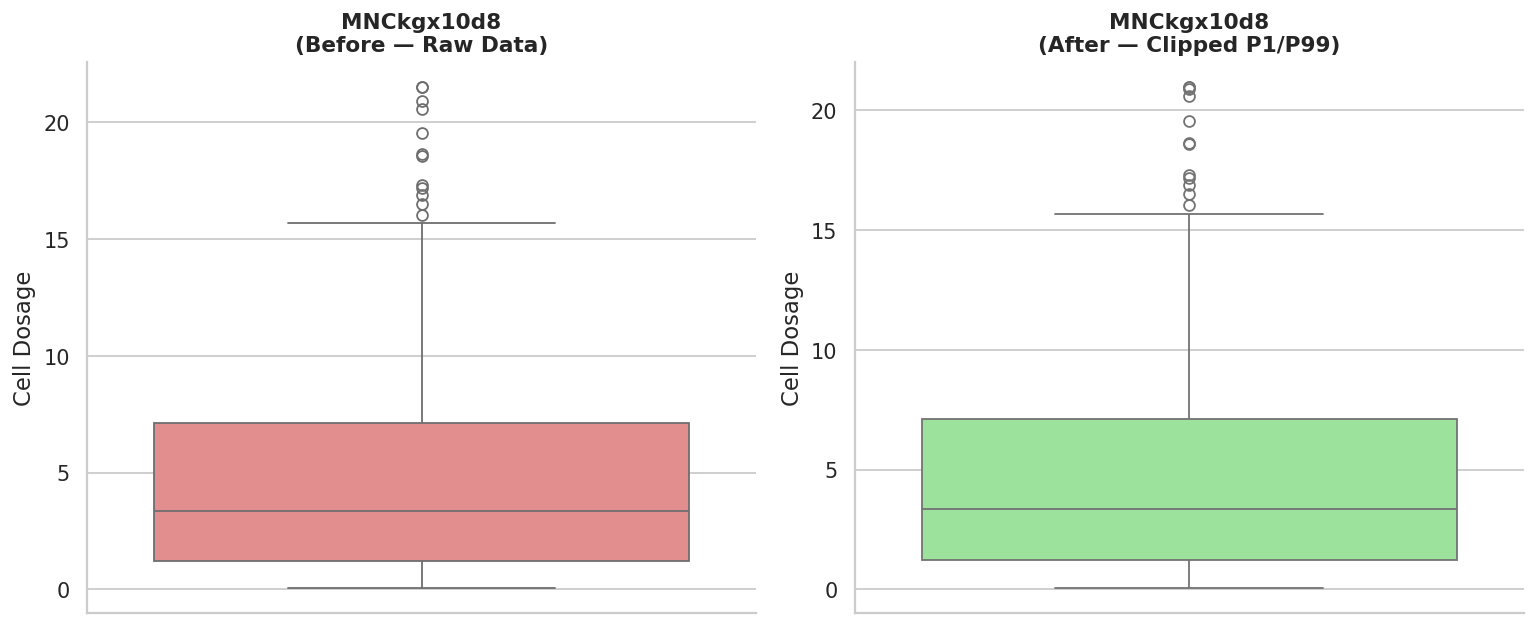

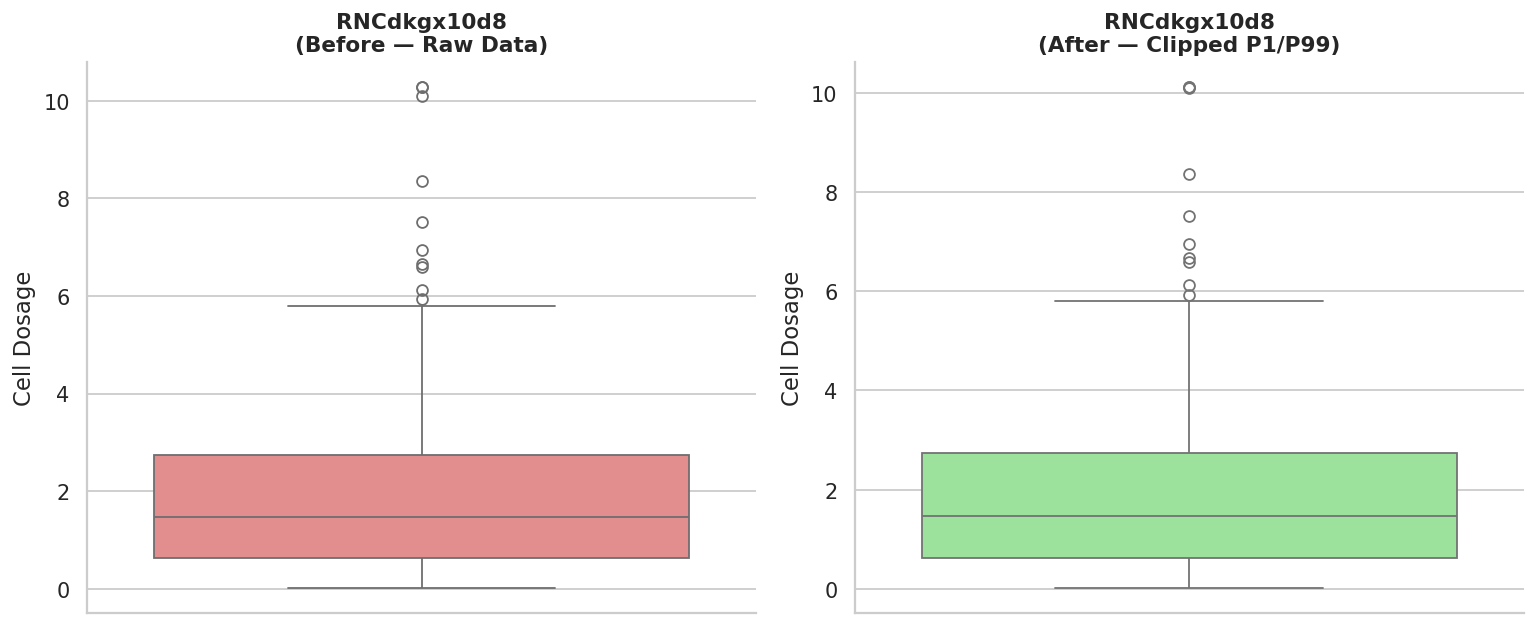

✓ Before/after outlier plots complete


In [13]:
# ── Before / After boxplots — ──────────
for col in clip_targets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(y=df_before_clip[col], ax=axes[0], color="lightcoral")
    axes[0].set_title(f"{col}\n(Before — Raw Data)", fontsize=12)
    axes[0].set_ylabel("Cell Dosage")
    sns.boxplot(y=df[col], ax=axes[1], color="lightgreen")
    axes[1].set_title(f"{col}\n(After — Clipped P1/P99)", fontsize=12)
    axes[1].set_ylabel("Cell Dosage")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{col}_before_after.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

print("✓ Before/after outlier plots complete")

---

## 10. Log Transformations

Strategy used: **`log(1 + x)`** (numpy `log1p`) — safe when `x = 0`, which occurs in clinical dosage variables. The original `log.py` on `CD34kgx10d6` only; this function generalises to all skewed columns identified in Section 6.


In [14]:
# ============================================================
#  10. LOG TRANSFORMATIONS
# ============================================================

def apply_log_transformations(
    df: pd.DataFrame,
    skewed_cols: List[str],
    strategy: str = "log1p",
) -> pd.DataFrame:
    """
    strategy='log1p'  → log(1+x)  [safe for zeros, preferred]
    strategy='log'    → log(x), replacing 0 with NaN then median-imputing
    """
    for col in skewed_cols:
        if col not in df.columns or col == TARGET_COL:
            continue
        new_col = f"log_{col}"
        if strategy == "log1p":
            df[new_col] = np.log1p(df[col])
        else:
            df[new_col] = np.log(df[col].replace(0, np.nan))
            df[new_col] = df[new_col].fillna(df[new_col].median())
        df = df.drop(columns=[col])
    return df


# ── Side-by-side histograms — log.py style ───────────────────
df_before_log = df.copy()

print("=" * 60)
print("  LOG(1+X) TRANSFORMATIONS")
print("=" * 60)
print(f"  {'Column':<22} {'Skew before':>12} {'Skew after':>12}")
print("-" * 60)

for col in [c for c in skewed_cols if c in df.columns and c != TARGET_COL]:
    sk_before = df[col].skew()
    log_col   = f"log_{col}"
    df[log_col] = np.log1p(df[col])
    sk_after  = df[log_col].skew()
    print(f"  {col:<22} {sk_before:>12.4f} {sk_after:>12.4f}")
    df = df.drop(columns=[col])

print("=" * 60)
print("✓ Log transformations applied")

  LOG(1+X) TRANSFORMATIONS
  Column                  Skew before   Skew after
------------------------------------------------------------
  RNCdkgx10d8                  1.9364       0.3928
  CD3dCD34                     2.1245       0.7861
  WBCx10d8                     2.0034      -0.0988
  CD3dkgx10d8                  1.4925       0.0943
  CD34kgx10d6                  1.6009       0.0672
  MNCkgx10d8                   1.5029       0.0815
✓ Log transformations applied


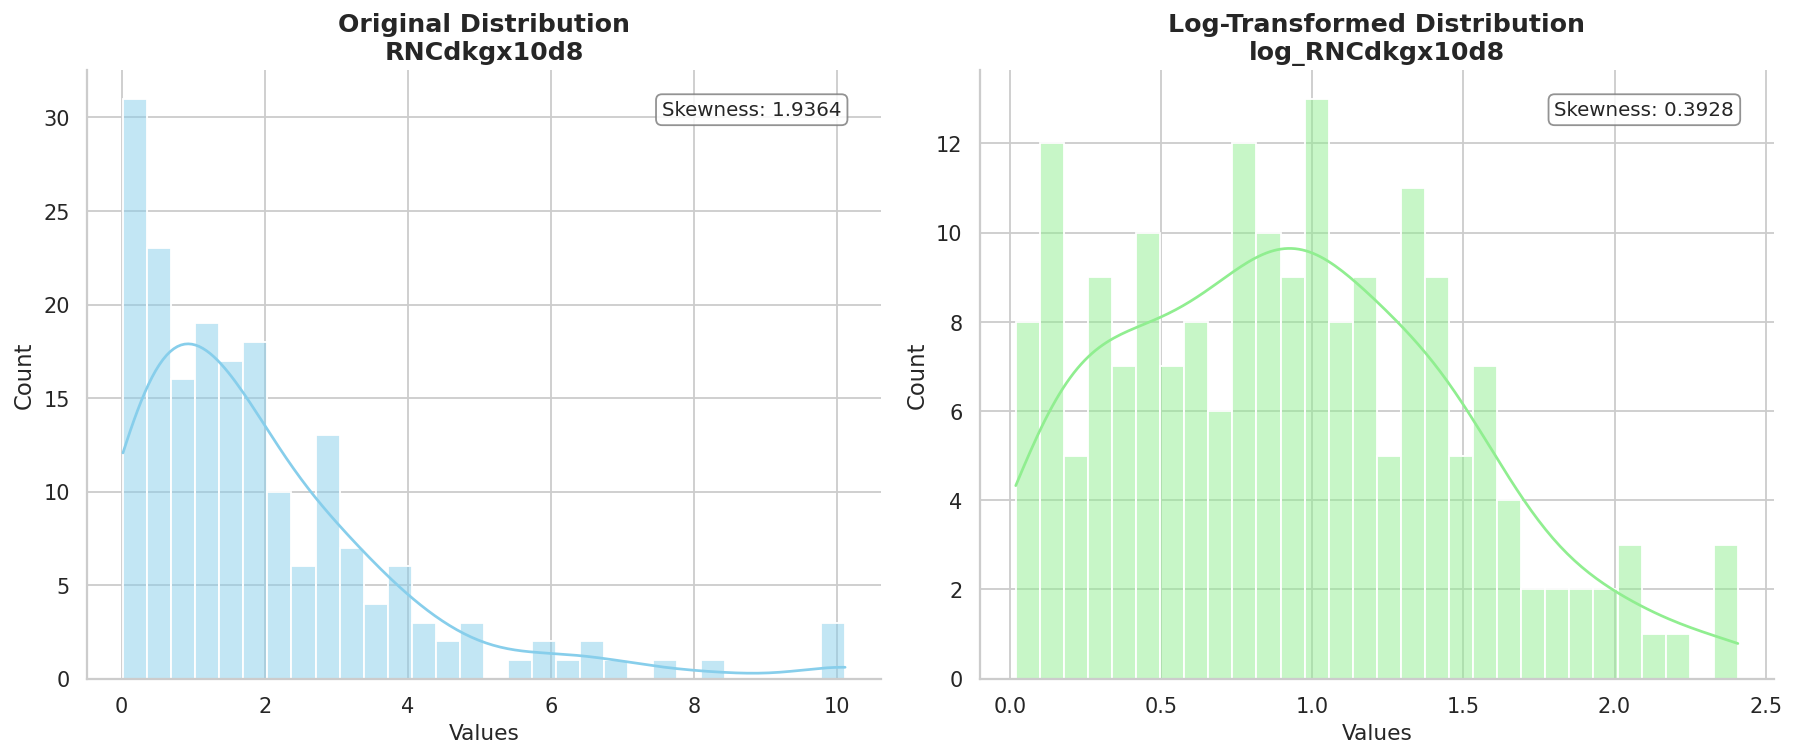

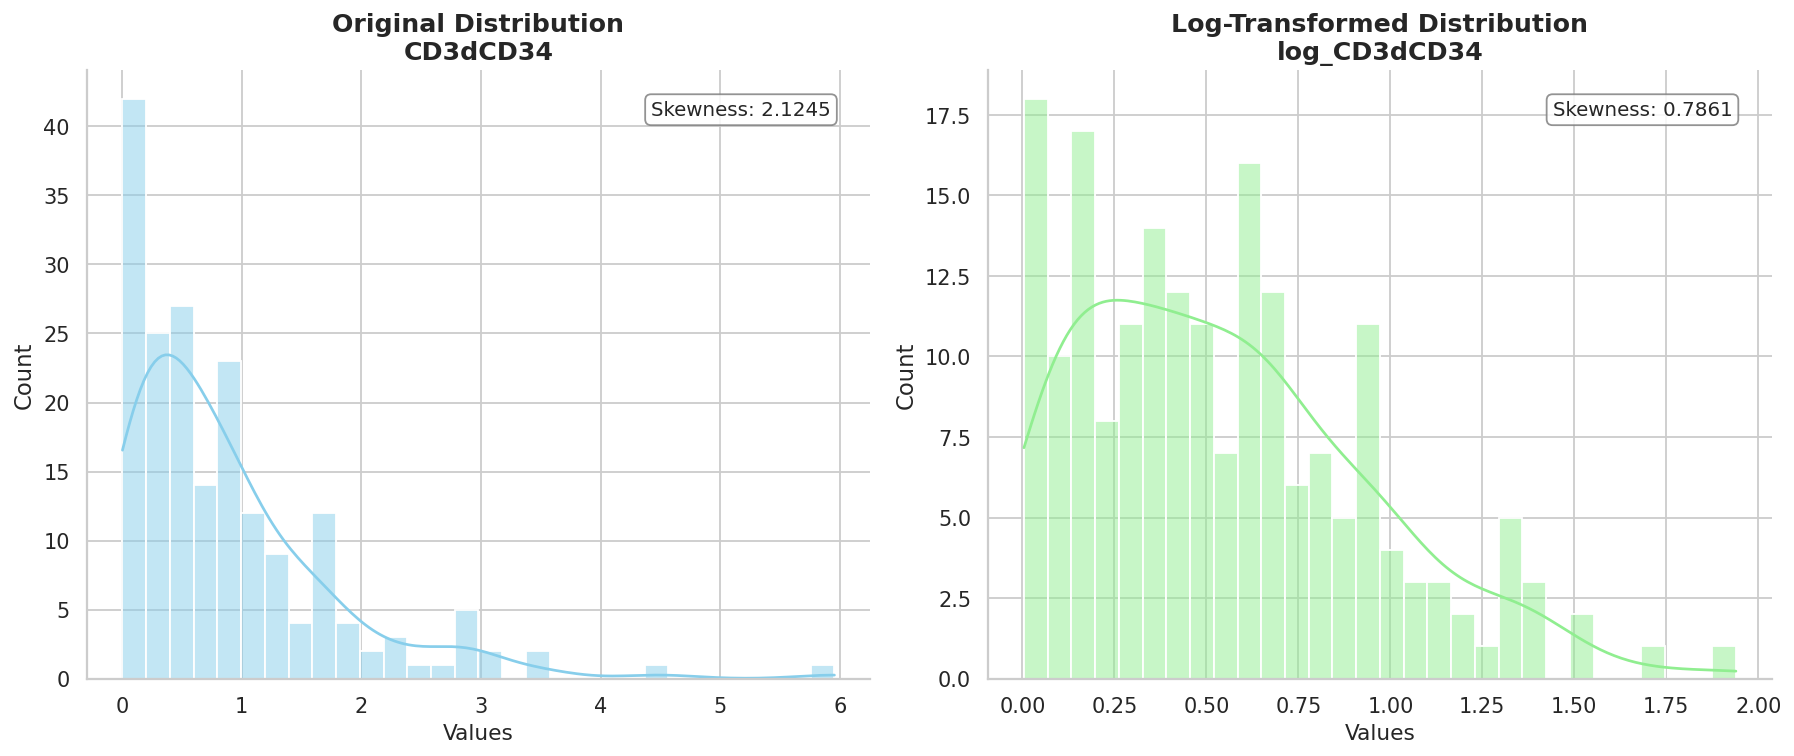

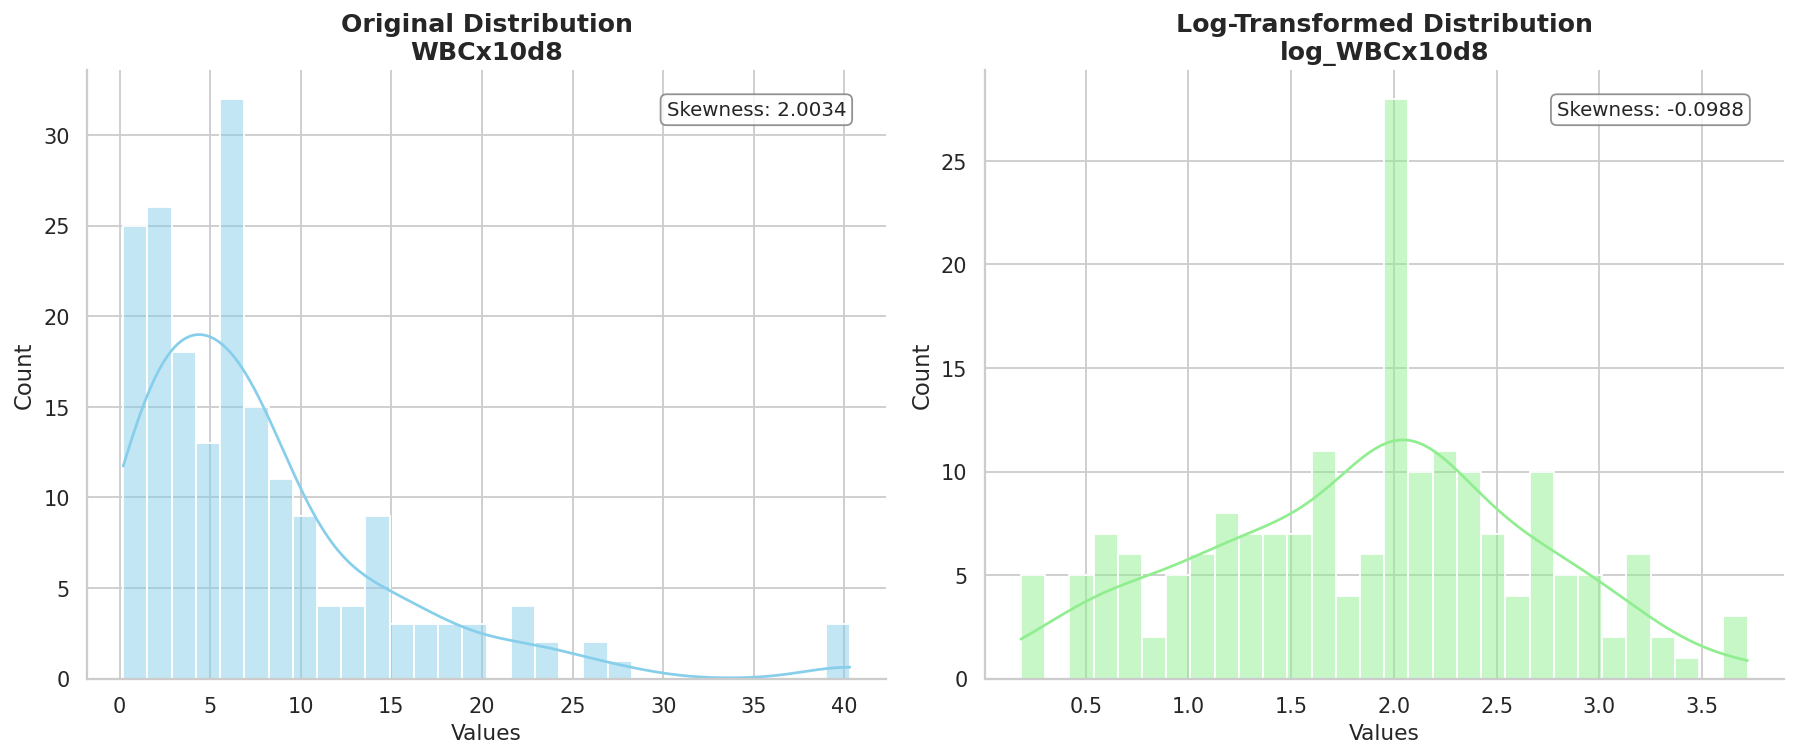

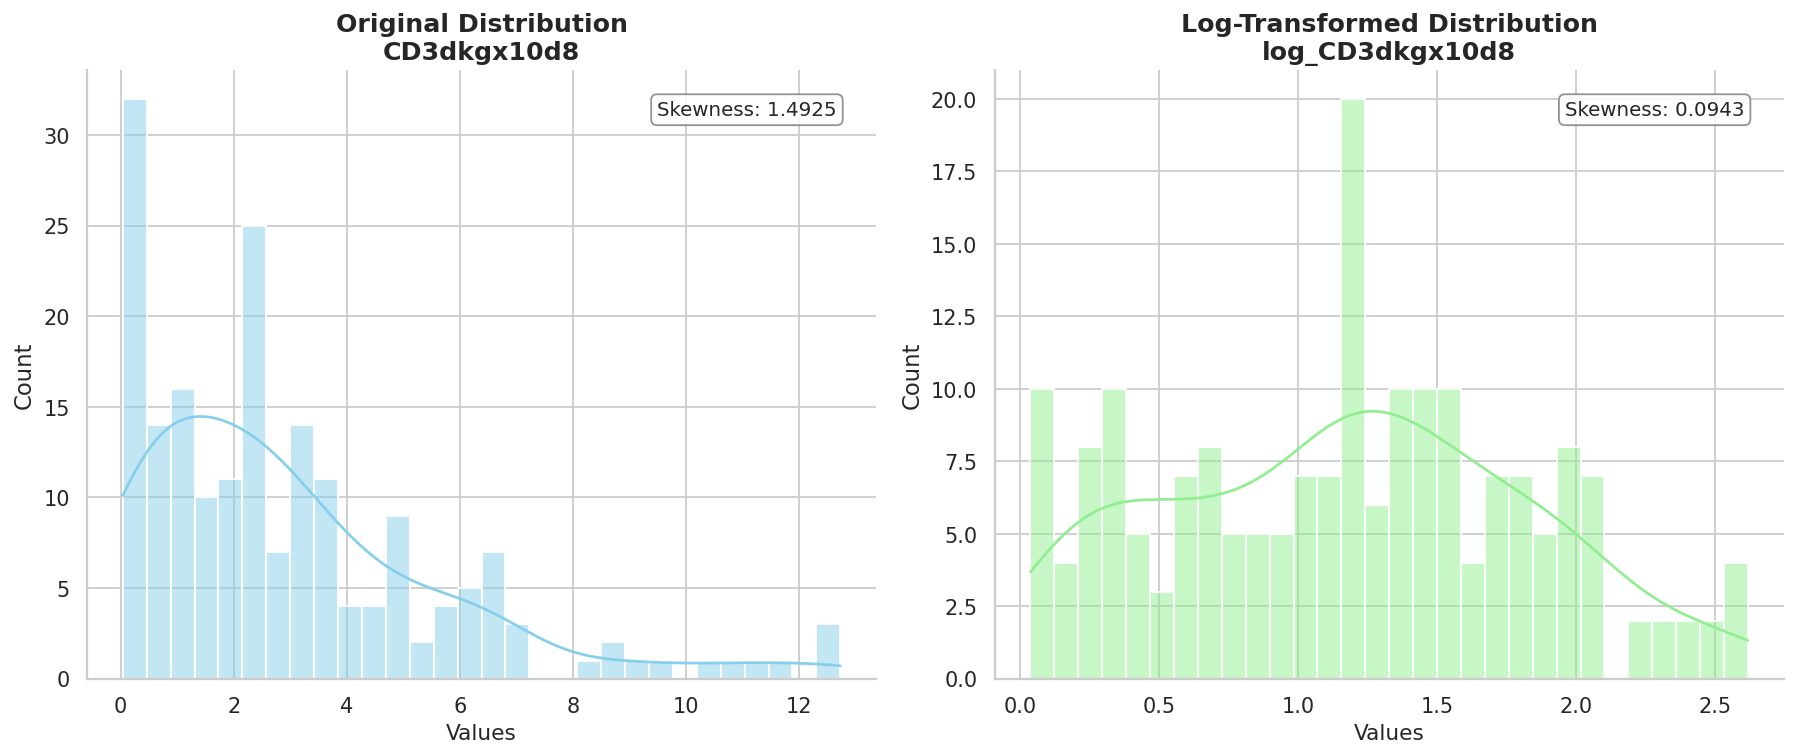

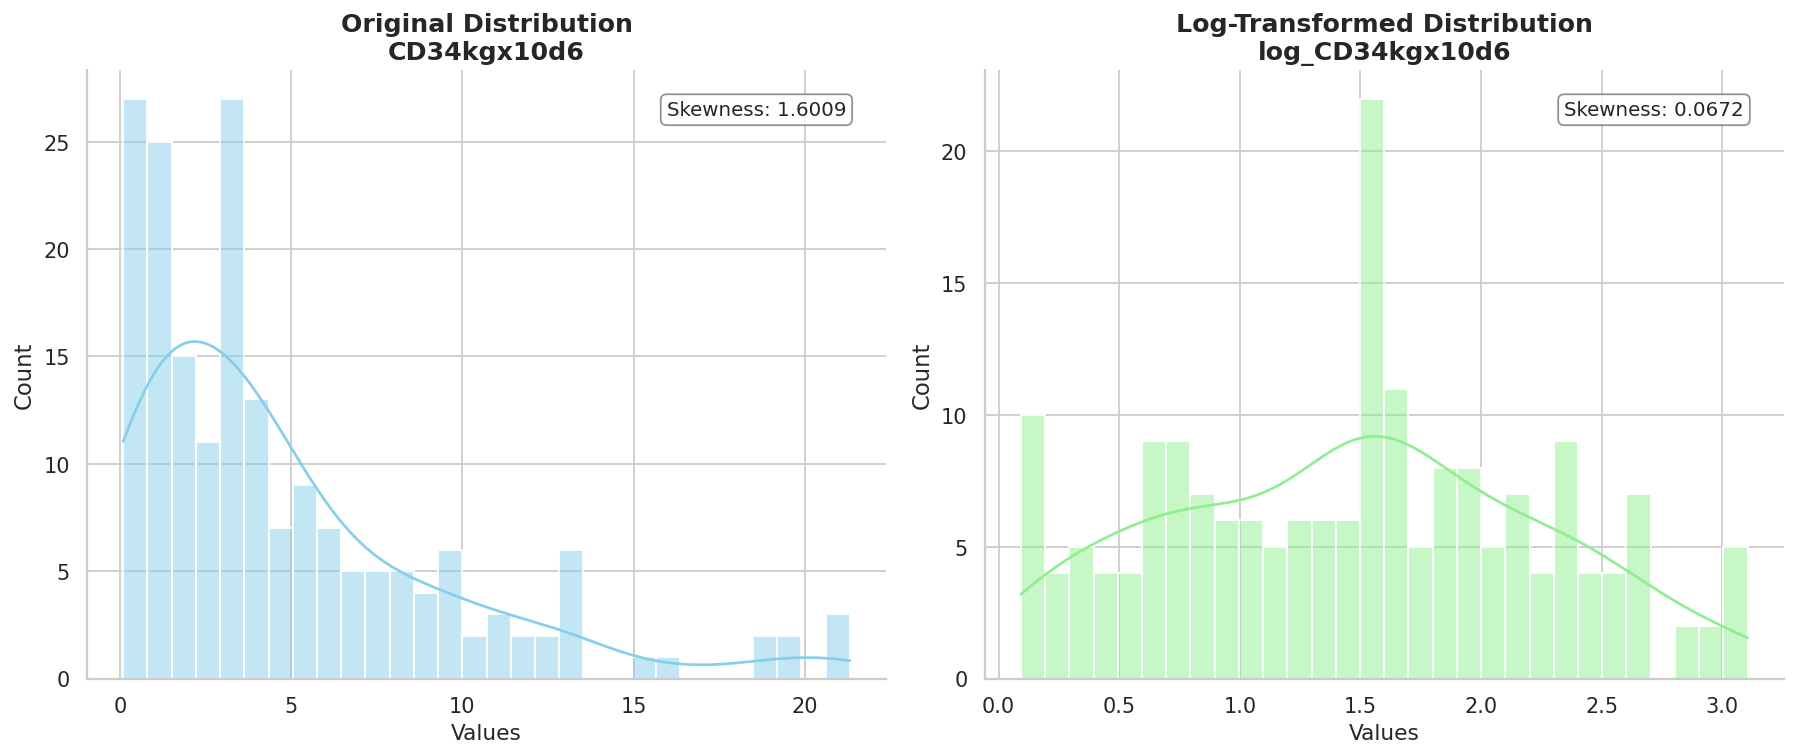

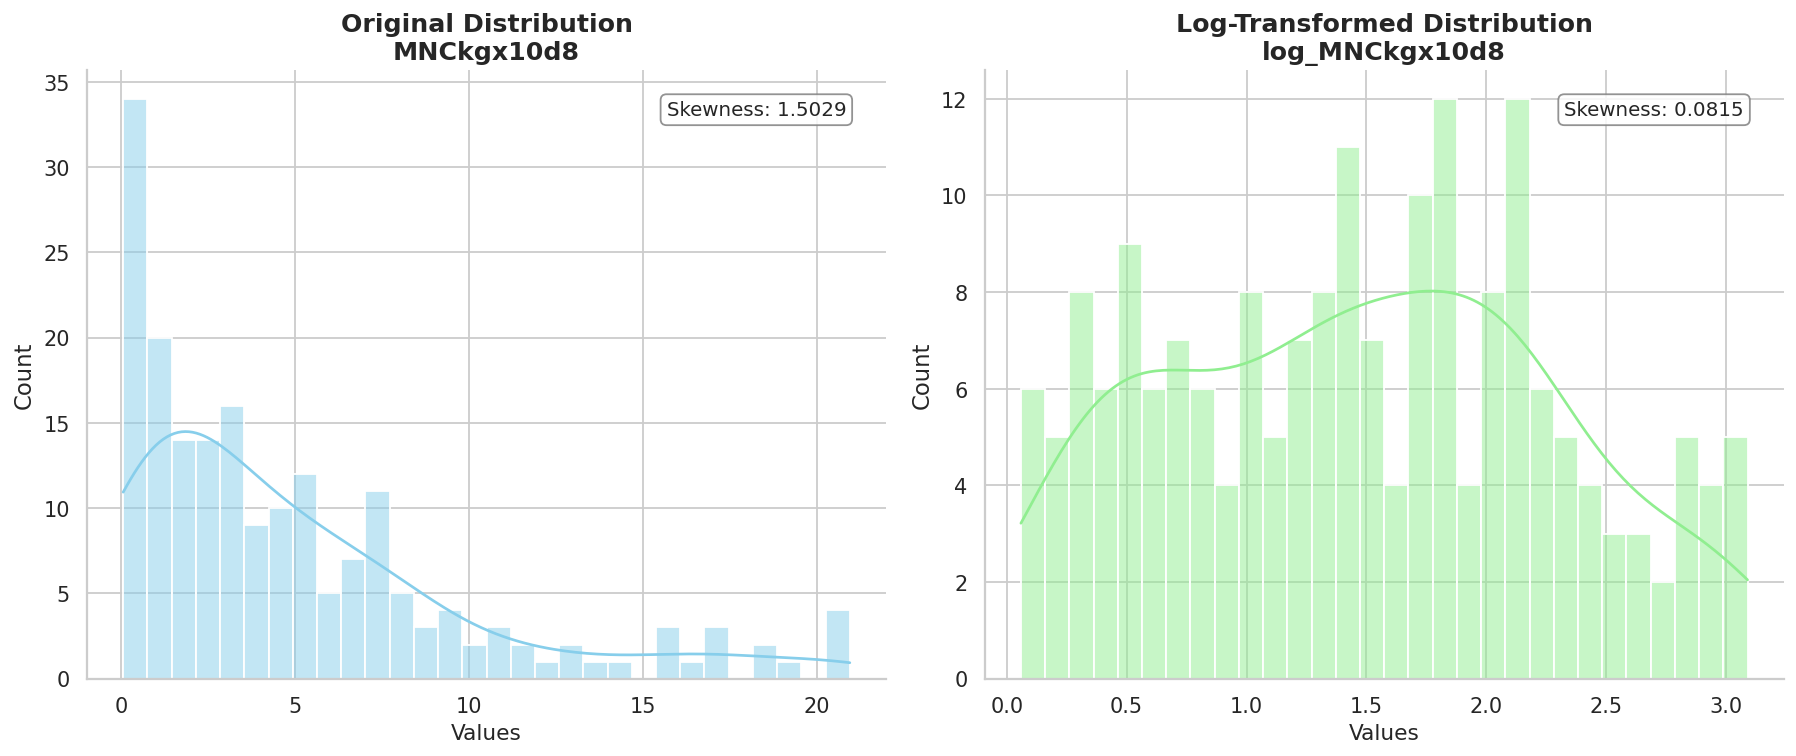

✓ Log transformation histograms complete


In [15]:
# ── Plot: Original vs Log-Transformed histograms —──
for col in skewed_cols:
    log_col = f"log_{col}"
    if col not in df_before_log.columns or log_col not in df.columns:
        continue

    sk_b = df_before_log[col].skew()
    sk_a = df[log_col].skew()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.histplot(df_before_log[col], kde=True, ax=axes[0], color="skyblue", bins=30)
    axes[0].set_title(f"Original Distribution\n{col}", fontsize=14)
    axes[0].set_xlabel("Values", fontsize=12)
    axes[0].text(0.95, 0.95, f"Skewness: {sk_b:.4f}",
                 transform=axes[0].transAxes, fontsize=11, va="top", ha="right",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="gray"))

    sns.histplot(df[log_col], kde=True, ax=axes[1], color="lightgreen", bins=30)
    axes[1].set_title(f"Log-Transformed Distribution\n{log_col}", fontsize=14)
    axes[1].set_xlabel("Values", fontsize=12)
    axes[1].text(0.95, 0.95, f"Skewness: {sk_a:.4f}",
                 transform=axes[1].transAxes, fontsize=11, va="top", ha="right",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="gray"))

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{col}_log_transformation.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

print("✓ Log transformation histograms complete")

---

## 11. Spearman Correlation Heatmap

**Why Spearman over Pearson?**  
- Clinical variables are rarely normally distributed  
- Spearman is rank-based → robust to the heavy-tailed distributions present in BMT data  
- Captures monotonic non-linear relationships

The special `Recipientage` / `Rbodymass` pair (identified in the original `Heat_map.py`) is checked explicitly.

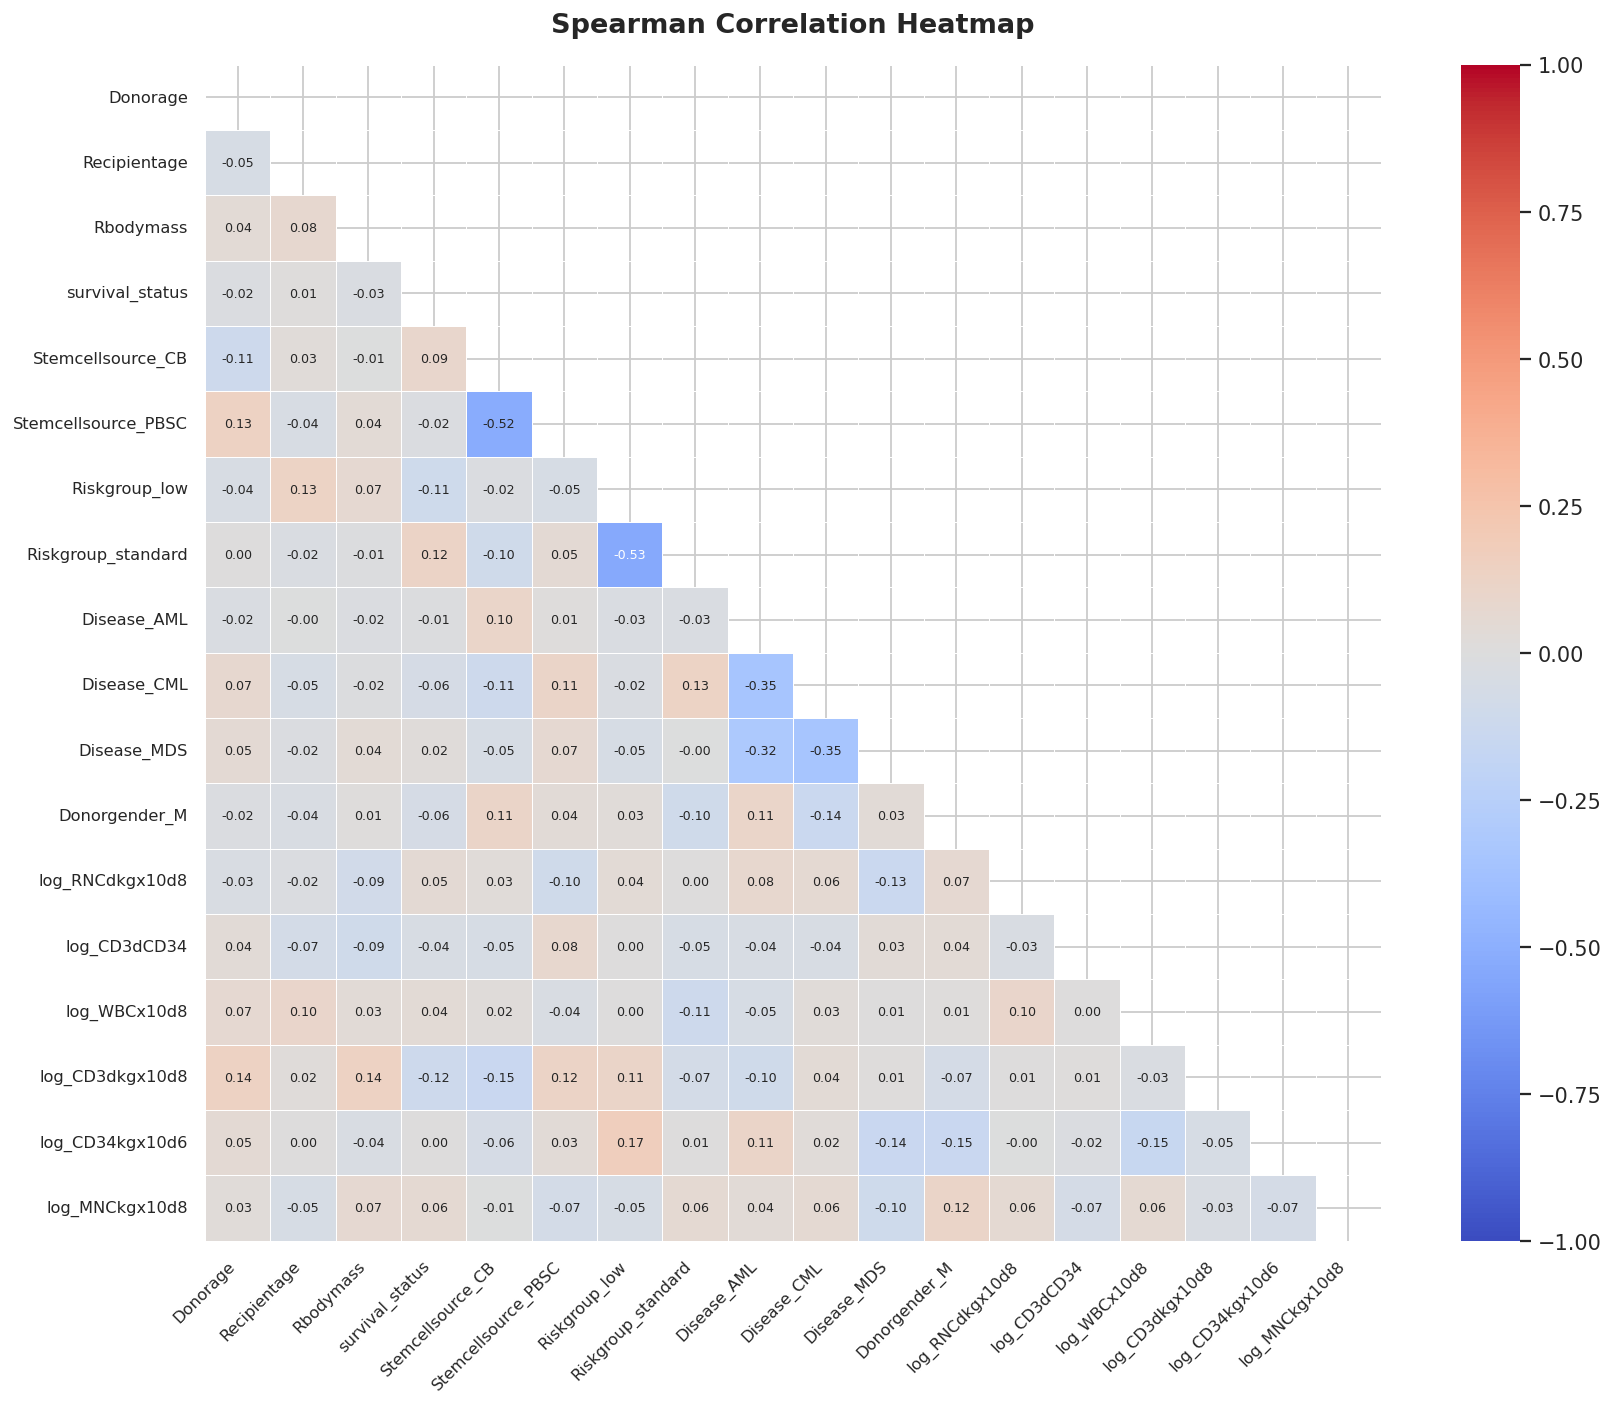

  HIGHLY CORRELATED PAIRS  (|ρ| > 0.8)
  ✓ No pair exceeds threshold


In [16]:
# ============================================================
#  11. SPEARMAN CORRELATION HEATMAP
# ============================================================

# Signed matrix for heatmap colours
corr_signed = df.corr(method="spearman")

# Absolute matrix for threshold logic
corr_abs    = corr_signed.abs()

# ── Heatmap ───────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_signed, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_signed, mask=mask,
    annot=True, cmap="coolwarm", fmt=".2f",
    vmax=1.0, vmin=-1.0, center=0,
    square=True, linewidths=0.5,
    annot_kws={"size": 7},
)
plt.title("Spearman Correlation Heatmap", fontsize=15, fontweight="bold", pad=18)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "spearman_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ── High-correlation pairs report (Heat_map.py style) ────────
print("=" * 60)
print(f"  HIGHLY CORRELATED PAIRS  (|ρ| > {MULTICOLLINEARITY_THRESHOLD})")
print("=" * 60)
found = False
for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        c1, c2 = corr_abs.columns[i], corr_abs.columns[j]
        val = corr_abs.iloc[i, j]
        if val > MULTICOLLINEARITY_THRESHOLD:
            print(f"  ⚠  {c1} & {c2}: ρ = {val:.2f}")
            found = True
if not found:
    print("  ✓ No pair exceeds threshold")

# Explicit Recipientage / Rbodymass check (Heat_map.py)
if "Recipientage" in corr_abs.columns and "Rbodymass" in corr_abs.columns:
    spec = corr_abs.loc["Recipientage", "Rbodymass"]
    if spec > 0.80:
        print("\n" + "!" * 60)
        print(f"  WARNING: Recipientage & Rbodymass  |ρ| = {spec:.2f} > 0.80")
        print("  Consider PCA or dropping one to prevent model instability.")
        print("!" * 60)
print("=" * 60)

---

## 12. Multicollinearity Reduction — Greedy Feature Selection


1. Sort features by `|ρ with survival_status|` descending
2. Iterate the list; **keep** a feature only if it does not exceed `MULTICOLLINEARITY_THRESHOLD` with any already-kept feature
3. When a feature is dropped, log which kept feature it was redundant with, and both features' target-correlation values

This ensures the feature with the **greatest predictive signal** is always retained — superior to the simple upper-triangle drop used in the original `data_processing.py`.

In [17]:
# ============================================================
#  12. MULTICOLLINEARITY REDUCTION — GREEDY FEATURE SELECTION
# ============================================================

def reduce_multicollinearity(
    df: pd.DataFrame,
    corr_matrix: pd.DataFrame,
    target_col: str = TARGET_COL,
) -> Tuple[pd.DataFrame, Dict, List]:
    """
    Greedy feature selection: keeps the feature with highest |ρ| to target
    when two features exceed MULTICOLLINEARITY_THRESHOLD with each other.
    """
    target_corr = corr_matrix[target_col].fillna(0).sort_values(ascending=False)
    features    = [f for f in target_corr.index if f != target_col and f in df.columns]

    keep: List[str]       = []
    drop: Dict[str, dict] = {}

    for feat in features:
        redundant_with = next(
            (k for k in keep if corr_matrix.loc[feat, k] > MULTICOLLINEARITY_THRESHOLD),
            None,
        )
        if redundant_with:
            drop[feat] = {
                "redundant_with":   redundant_with,
                "correlation":      round(float(corr_matrix.loc[feat, redundant_with]), 4),
                "feat_target_corr": round(float(target_corr[feat]), 4),
                "kept_target_corr": round(float(target_corr[redundant_with]), 4),
            }
        else:
            keep.append(feat)

    cols_to_use = [c for c in keep + [target_col] if c in df.columns]
    return df[cols_to_use], drop, keep


df, drop_report, kept_features = reduce_multicollinearity(df, corr_abs)

print("=" * 60)
print("  DROPPED COLUMNS & RATIONALE")
print("=" * 60)
if drop_report:
    for col, info in drop_report.items():
        print(f"  ✗ '{col}'")
        print(f"      Correlates {info['correlation']:.2f} with '{info['redundant_with']}'")
        print(f"      Kept '{info['redundant_with']}': target_corr {info['kept_target_corr']:.4f} "
              f"> {info['feat_target_corr']:.4f}")
else:
    print("  ✓ No features dropped — no multicollinearity detected")

print("-" * 60)
print(f"  Final feature count : {len(kept_features)}")
print(f"  Final shape         : {df.shape}")
print("=" * 60)
print("✓ Multicollinearity reduction complete")

  DROPPED COLUMNS & RATIONALE
  ✓ No features dropped — no multicollinearity detected
------------------------------------------------------------
  Final feature count : 17
  Final shape         : (190, 18)
✓ Multicollinearity reduction complete


---

## 13. Bivariate Analysis & Class Distribution


- **Bivariate plots**: boxplots of key features vs `survival_status`
- **Class distribution**: bar chart of class counts and minority class percentage
- **Categorical survival plots**: count-plots by `Stemcellsource`, `Riskgroup`, `Disease`, `Donorgender`
- **Skew-check (other)**: histogram checks for `CD3dkgx10d8`, `WBCx10d8`, `MNCkgx10d8`, `RNCdkgx10d8`

19:52:10  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:52:10  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:52:10  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:52:10  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:52:10  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, c

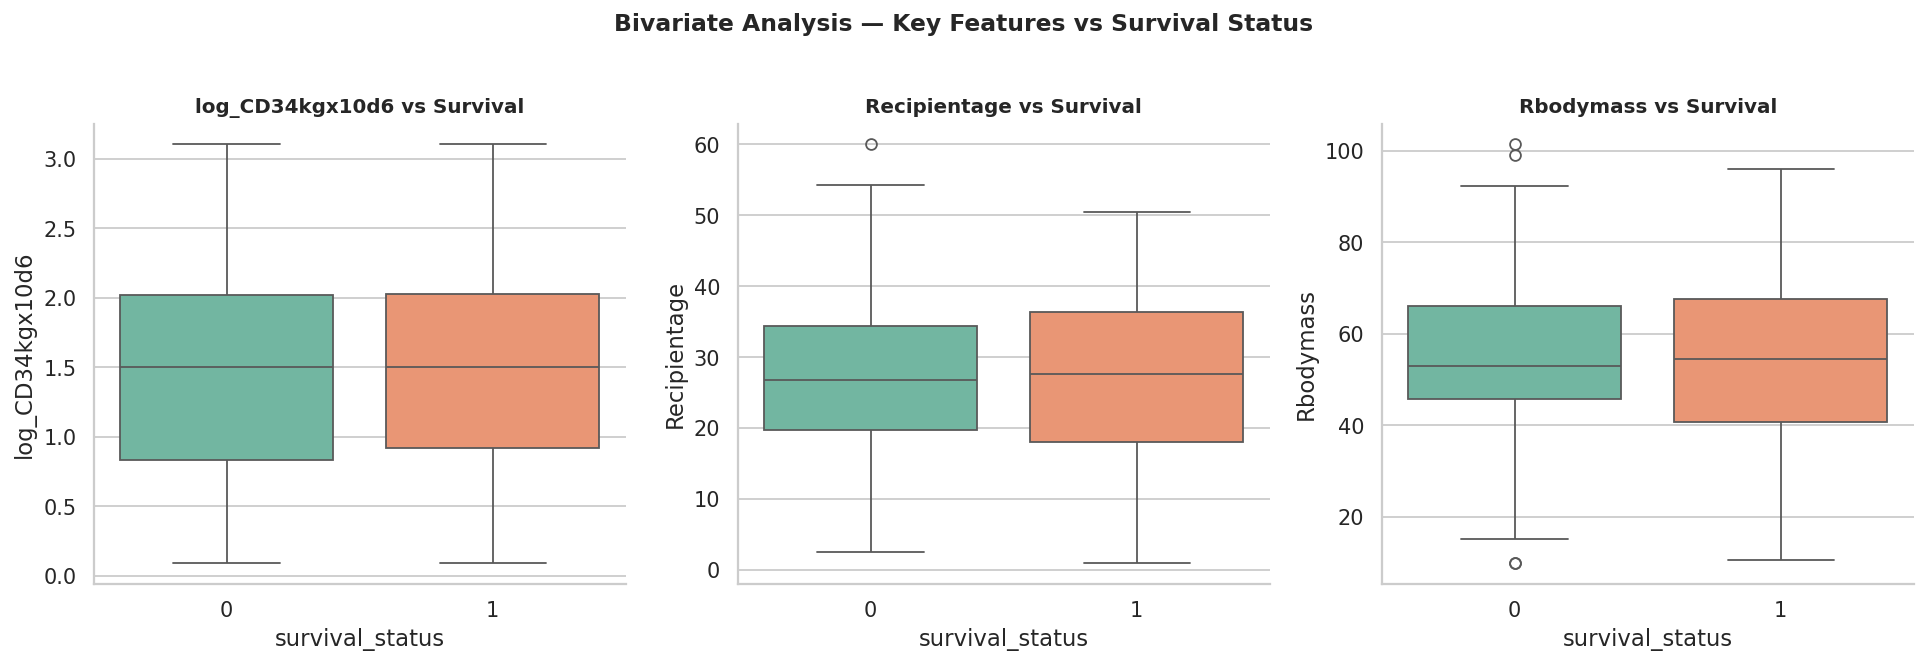

✓ Bivariate analysis plots complete


In [19]:
# ============================================================
#  13a. BIVARIATE ANALYSIS
# ============================================================

bivariate_cols = [c for c in ["log_CD34kgx10d6", "CD34kgx10d6", "Recipientage", "Rbodymass"]
                  if c in df.columns]

if bivariate_cols and TARGET_COL in df.columns:
    fig, axes = plt.subplots(1, len(bivariate_cols), figsize=(5 * len(bivariate_cols), 5))
    if len(bivariate_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, bivariate_cols):
        sns.boxplot(x=TARGET_COL, y=col, data=df, ax=ax, palette="Set2")
        ax.set_title(f"{col} vs Survival", fontsize=11)
    plt.suptitle("Bivariate Analysis — Key Features vs Survival Status",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "bivariate_survival.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("✓ Bivariate analysis plots complete")
else:
    print("⚠ Bivariate plot skipped — columns not available after pipeline")

19:52:20  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:52:21  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


  CLASS DISTRIBUTION
  Class 0:  106 (55.8%)
  Class 1:   84 (44.2%)
  Minority class : 44.21%


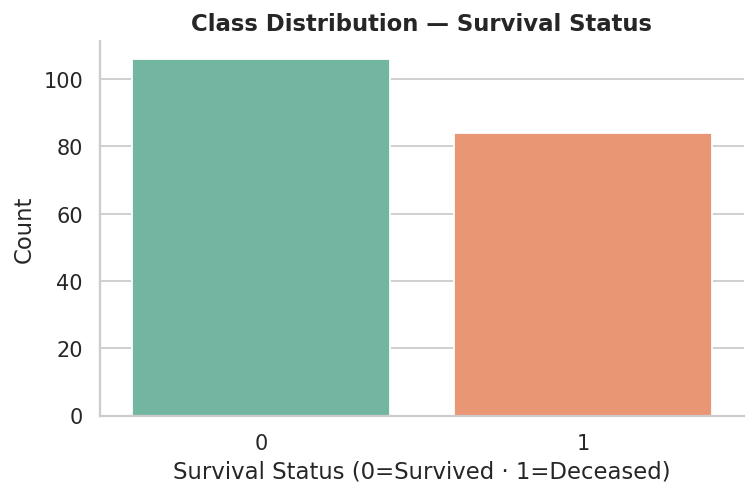

✓ Class distribution plot complete


In [20]:
# ============================================================
#  13b. CLASS DISTRIBUTION
# ============================================================

if TARGET_COL in df.columns:
    counts       = df[TARGET_COL].value_counts().sort_index()
    minority_pct = (counts.min() / counts.sum()) * 100

    print("=" * 50)
    print("  CLASS DISTRIBUTION")
    print("=" * 50)
    for cls, cnt in counts.items():
        print(f"  Class {cls}: {cnt:>4} ({cnt/counts.sum()*100:.1f}%)")
    print(f"  Minority class : {minority_pct:.2f}%")
    print("=" * 50)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Set2")
    plt.title("Class Distribution — Survival Status", fontweight="bold")
    plt.ylabel("Count")
    plt.xlabel("Survival Status (0=Survived · 1=Deceased)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("✓ Class distribution plot complete")

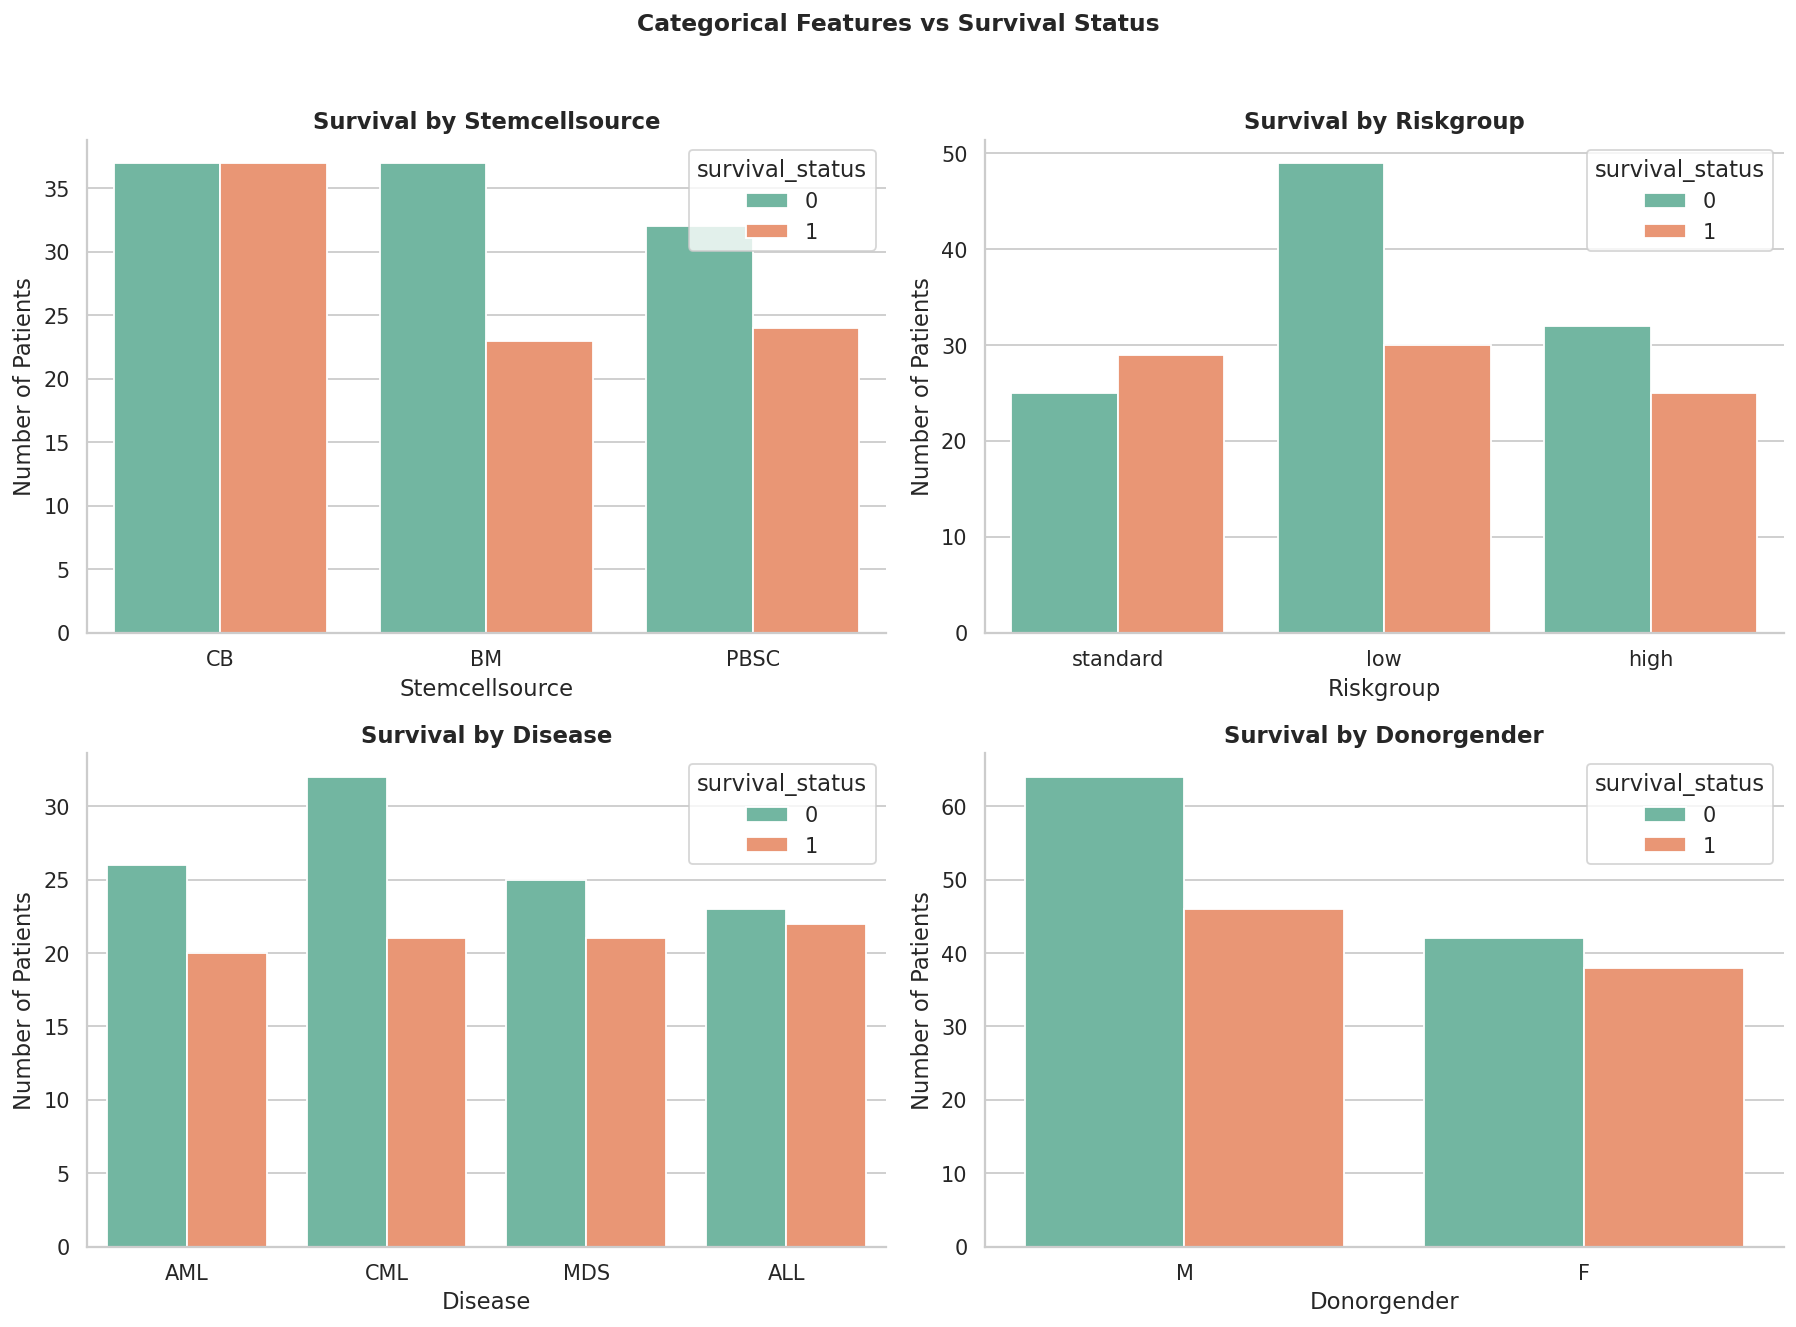

✓ Categorical survival plots complete


In [21]:
# ============================================================
#  13c. CATEGORICAL SURVIVAL PLOTS
# ============================================================

existing_cats = [c for c in CATEGORICAL_FEATURES if c in df_raw.columns]

if existing_cats and TARGET_COL in df_raw.columns:
    nrows = (len(existing_cats) + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 5 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(existing_cats):
        sns.countplot(data=df_raw, x=col, hue=TARGET_COL, ax=axes[i], palette="Set2")
        axes[i].set_title(f"Survival by {col}", fontweight="bold")
        axes[i].set_ylabel("Number of Patients")
    for j in range(len(existing_cats), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Categorical Features vs Survival Status",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "categorical_survival.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("✓ Categorical survival plots complete")
else:
    print("⚠ Categorical survival plot skipped — columns not found in raw data")

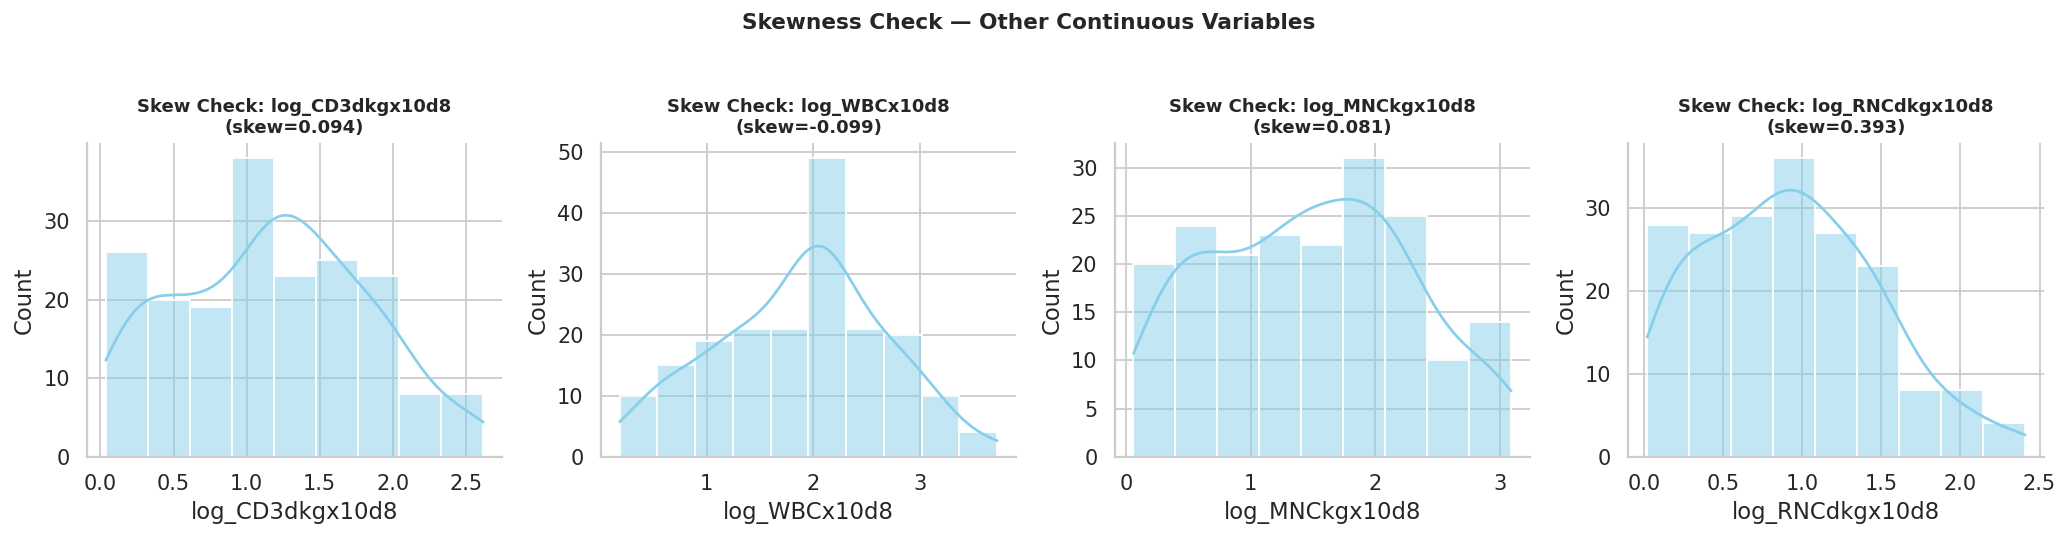

✓ Skew-check plots complete


In [22]:
# ============================================================
#  13d. SKEW-CHECK — OTHER CONTINUOUS VARIABLES
# ============================================================

# These may be log-transformed by now; check both original and log names
check_other = []
for col in ["CD3dkgx10d8", "WBCx10d8", "MNCkgx10d8", "RNCdkgx10d8"]:
    if col in df.columns:
        check_other.append(col)
    elif f"log_{col}" in df.columns:
        check_other.append(f"log_{col}")

if check_other:
    fig, axes = plt.subplots(1, len(check_other), figsize=(4 * len(check_other), 4))
    if len(check_other) == 1:
        axes = [axes]
    for ax, col in zip(axes, check_other):
        sns.histplot(df[col], kde=True, ax=ax, color="skyblue")
        ax.set_title(f"Skew Check: {col}\n(skew={df[col].skew():.3f})", fontsize=10)
    plt.suptitle("Skewness Check — Other Continuous Variables",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "skew_check_other.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("✓ Skew-check plots complete")

---

## 14. Save Outputs & Pipeline Report

**Source script:** `Focused-data.py` (JSON export) + `data_processing.py` (CSV save)

Two outputs:
- `data/processed/bmt_dataset_focused.csv` — final preprocessed dataset ready for model training
- `data/reports/pipeline_report.json` — machine-readable audit trail

In [23]:
# ============================================================
#  14. SAVE OUTPUTS & PIPELINE REPORT
# ============================================================

# ── Save focused dataset ──────────────────────────────────────
focused_path = PROCESSED_DIR / "bmt_dataset_focused.csv"
df.to_csv(focused_path, index=False)

# ── Save JSON report ──────────────────────────────────────────
report = {
    "shape_final":            list(df.shape),
    "skewed_cols_identified": skewed_cols,
    "dropped_multicollinear": drop_report,
    "features_kept":          kept_features,
    "iqr_outlier_count":      len(iqr_idx),
    "zscore_outlier_count":   len(z_idx),
    "features_final":         [c for c in df.columns if c != TARGET_COL],
}
report_path = REPORTS_DIR / "pipeline_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("=" * 60)
print("  PIPELINE COMPLETE — OUTPUT SUMMARY")
print("=" * 60)
print(f"  ✓ Dataset   : {focused_path}")
print(f"       Shape  : {df.shape[0]} rows × {df.shape[1]} cols")
print(f"  ✓ Report    : {report_path}")
print(f"  ✓ Plots dir : {PLOTS_DIR}")
print("=" * 60)

  PIPELINE COMPLETE — OUTPUT SUMMARY
  ✓ Dataset   : data/processed/bmt_dataset_focused.csv
       Shape  : 190 rows × 18 cols
  ✓ Report    : data/reports/pipeline_report.json
  ✓ Plots dir : data/plots


---

## 15. Pipeline Summary

Full audit trail of every step executed in this notebook.

In [24]:
# ============================================================
#  15. PIPELINE SUMMARY
# ============================================================

print("=" * 72)
print("  CLINICAL ML — BMT PIPELINE SUMMARY")
print("=" * 72)
print(f"  {'Step':<4} {'Action':<35} {'Result'}")
print("-" * 72)

summary_rows = [
    ("1",  "Load raw data",                     f"{df_raw.shape[0]} rows × {df_raw.shape[1]} cols"),
    ("2",  "Drop leakage columns",               str([c for c in DROP_COLUMNS if c in df_raw.columns])),
    ("3",  "Median/mode imputation",             f"{df_raw.isnull().sum().sum()} NaNs filled"),
    ("4",  "One-hot encode + downcast",          "Memory optimised"),
    ("5",  "Statistical profiling",              f"reports/statistical_profile.csv"),
    ("6",  "Distribution analysis",             f"{len(skewed_cols)} skewed cols (|s|>{SKEWNESS_THRESHOLD})"),
    ("7",  "Per-variable dist. plots",           f"{len([c for c in DISTRIBUTION_FEATURES if c in df_raw.columns])} plots"),
    ("8",  "Outlier detection",                  f"IQR: {len(iqr_idx)} rows · Z-score: {len(z_idx)} rows"),
    ("9",  "P1/P99 clipping",                   f"{len(clip_targets)} columns clipped"),
    ("10", "Log(1+x) transformations",           f"{len(skewed_cols)} columns transformed"),
    ("11", "Spearman heatmap",                   "plots/spearman_heatmap.png"),
    ("12", "Multicollinearity reduction",        f"{len(drop_report)} dropped · {len(kept_features)} kept"),
    ("13", "Bivariate & class dist. plots",      "4 plot files"),
    ("14", "Save outputs",                       f"bmt_dataset_focused.csv  {df.shape}"),
]

for step, action, result in summary_rows:
    print(f"  {step:<4} {action:<35} {result}")

print("=" * 72)
print("  ✓ Dataset ready for model training")
print("=" * 72)

  CLINICAL ML — BMT PIPELINE SUMMARY
  Step Action                              Result
------------------------------------------------------------------------
  1    Load raw data                       190 rows × 17 cols
  2    Drop leakage columns                ['id', 'survival_time', 'Relapse']
  3    Median/mode imputation              45 NaNs filled
  4    One-hot encode + downcast           Memory optimised
  5    Statistical profiling               reports/statistical_profile.csv
  6    Distribution analysis               6 skewed cols (|s|>0.75)
  7    Per-variable dist. plots            6 plots
  8    Outlier detection                   IQR: 51 rows · Z-score: 17 rows
  9    P1/P99 clipping                     5 columns clipped
  10   Log(1+x) transformations            6 columns transformed
  11   Spearman heatmap                    plots/spearman_heatmap.png
  12   Multicollinearity reduction         0 dropped · 17 kept
  13   Bivariate & class dist. plots       4 plot file